# Workflow 与 agent

本指南梳理常见的 workflow 与 agent 模式。

- Workflow 的代码路径是预先确定的, 并按特定顺序运行。
- Agent 是动态的, 它们自行决定流程与 tool 的使用方式。

![Agent Workflow](https://docs.langchain.com/oss/images/agent_workflow.png)

在构建 agents 与 workflows 时, LangGraph 提供了多项优势, 包括 [persistence](https://docs.langchain.com/oss/langgraph/persistence)、[streaming](https://docs.langchain.com/oss/langgraph/streaming), 以及对调试与 [部署](https://docs.langchain.com/oss/langgraph/deploy) 的支持。

In [1]:
# 环境准备: 从 .env 加载 API keys
from dotenv import load_dotenv

load_dotenv()  # 自动向上查找仓库根目录的 .env

# ---- 统一导入 ----
import operator
from dataclasses import dataclass
from typing import Annotated, List, Literal

from typing_extensions import TypedDict

from IPython.display import Markdown
from langchain.chat_models import init_chat_model
from langchain.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolCall,
    ToolMessage,
)
from langchain.tools import ToolRuntime, tool
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task
from langgraph.graph import END, START, MessagesState, StateGraph, add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
from pydantic import BaseModel, Field

In [2]:
from IPython.display import display, Image
from langgraph.graph.state import CompiledStateGraph

def show_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

from rich import print as rprint


## 环境准备

构建 workflow 或 agent 时, 你可以使用[任何支持结构化输出与 tool calling 的 chat model](https://docs.langchain.com/oss/integrations/chat)。下面的示例使用 DeepSeek 的 chat model。

In [3]:
llm = init_chat_model("deepseek:deepseek-chat", temperature=0)

## LLM 与增强

Workflows 与 agentic 系统都以 LLM 以及你为其添加的各种增强能力为基础。[Tool calling](https://docs.langchain.com/oss/langchain/tools)、[structured outputs](https://docs.langchain.com/oss/langchain/structured-output) 与 [short term memory](https://docs.langchain.com/oss/langchain/short-term-memory) 只是按需定制 LLM 的几种可选手段。

![LLM augmentations](https://docs.langchain.com/oss/images/augmented_llm.png)

In [4]:
# Schema for structured output
class SearchQuery(BaseModel):
    search_query: str | None = Field(
        default=None, description="Query that is optimized web search."
    )
    justification: str | None = Field(
        default=None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")
rprint(output)  # The model returns an instance of SearchQuery.

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")
rprint(msg.tool_calls)  # The model returns a request to call the tool.

SearchQuery(
    search_query='coronary artery calcium score relationship with high cholesterol',
    justification='To find evidence on how coronary calcium CT scores relate to elevated cholesterol levels.'
)

[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_00_uvloCugvxDcnIEO4Mvi84989', 'type': 'tool_call'}]

## Prompt chaining

Prompt chaining 指的是每一次 LLM 调用都处理上一次调用的输出。它常用于执行那些可以拆解成更小、可验证步骤的明确定义的任务。示例如下:

- 把文档翻译成不同语言
- 校验生成内容的一致性

![Prompt chaining](https://docs.langchain.com/oss/images/prompt_chain.png)

### Graph API

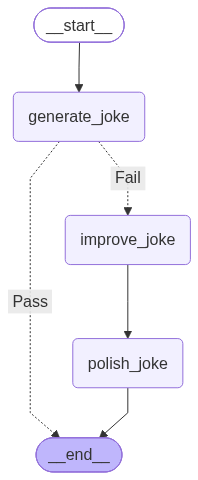

Initial joke:

Why did the cat join the band?

Because he was a purr-cussionist.

--- --- ---

Final joke:

Why did the cat join the band?

Because he was a purr-cussionist.

In [5]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
show_graph(chain)

# Invoke
state = chain.invoke({"topic": "cats"})
rprint("Initial joke:")
rprint(state["joke"])
rprint("\n--- --- ---\n")
if "improved_joke" in state:
    rprint("Improved joke:")
    rprint(state["improved_joke"])
    rprint("\n--- --- ---\n")

    rprint("Final joke:")
    rprint(state["final_joke"])
else:
    rprint("Final joke:")
    rprint(state["joke"])

### Functional API

In [6]:
# Tasks
@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()

# Invoke
stream = prompt_chaining_workflow.stream_events("cats", version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


[{'type': 'text', 'text': 'Why did the cat join the band?\n\nBecause he was a purr-cussionist.', 'index': 0}]

## Parallelization

使用并行化时, 多个 LLM 同时处理一项任务。这既可以是同时运行多个彼此独立的子任务, 也可以是重复运行同一个任务以检查不同输出。并行化常用于:

- 拆分并并行运行子任务, 从而提升速度
- 多次运行任务以检查不同输出, 从而提升置信度

示例如下:

- 一个子任务从文档中提取关键词, 另一个子任务检查格式错误
- 多次运行同一个任务, 依据不同标准(例如引用数量、使用的来源数量、来源质量)对文档的准确性打分

![parallelization.png](https://docs.langchain.com/oss/images/parallelization.png)

### Graph API

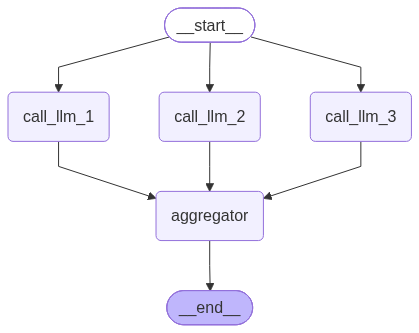

Here's a story, joke, and poem about cats!

STORY:
In the heart of the sleepy seaside town of Portmeow, where the cobblestones were worn smooth by time and the scent 
of salt and fish hung perpetually in the air, there lived a cat named Jasper. He was a ginger tom with fur the 
colour of a sunset and eyes like polished sea glass. Jasper was not a pet. He was a fixture, as much a part of the 
town as the lighthouse on the hill or the old wooden pier.

Jasper’s world was one of routine. He began his day with a stretch on the sun-warmed step of the "Salty Scone" 
bakery, where the baker’s wife, Elara, would leave out a saucer of cream. Then, he would patrol the harbour, 
exchanging a dignified sniff with the fishermen who knew him by name. His afternoons were for napping in the window
of the bookshop, "A Novel Idea," his tail twitching as he dreamt of chasing gulls.

But Jasper was lonely. He was the king of a kingdom of one.

One stormy autumn night, as the wind howled like a banshee and the rain lashed against the windows, a small, 
trembling shape appeared at the back door of the bakery. It was a kitten, a tiny scrap of black fur with enormous, 
frightened amber eyes. She was soaked to the bone and shivering so hard she could barely stand.

Jasper, who had been curled up on a flour sack, felt a stir of something he hadn't felt in years. Annoyance, at 
first. This was *his* warm spot. But as he watched the little creature, a different feeling took over. It was a 
feeling he’d long forgotten: a sense of responsibility.

He nudged the kitten with his nose, guiding her towards the warmth of the ovens. He licked her fur, a rough, 
sandpapery comfort, until she stopped shivering. He didn't know her name, so he called her Shadow, for she was as 
dark as the night she’d arrived.

Shadow was everything Jasper was not. She was clumsy, curious, and utterly fearless. She chased leaves that 
skittered across the pavement, pounced on Jasper’s tail as he tried to sleep, and asked a million questions in her 
tiny, squeaky meows.

“Why do the big birds scream?” she’d ask, watching the gulls.

“They’re not screaming,” Jasper would reply with a sigh. “They’re arguing. It’s what they do.”

“Why does the big water move?”

“It’s breathing, little one. The sea is always breathing.”

Jasper found his patience tested, but he also found a new purpose. He taught Shadow how to stalk a sunbeam, the 
correct way to sharpen her claws on the old oak tree by the pier, and the crucial art of looking pitiful enough to 
get a piece of fish from the market vendors. He showed her the best hiding spots and the warmest sleeping places. 
In turn, Shadow brought a chaotic, joyful energy into his structured life. She made him see his town through new 
eyes, full of wonder and discovery.

One day, a new cat arrived in Portmeow. He was a sleek, grey tom with a torn ear and a swagger that spoke of city 
streets and hard-won battles. He called himself Titan and he decided that the harbour, with its plentiful fish 
scraps, was his new territory. He challenged Jasper, hissing and posturing on the pier.

Jasper, who had always ruled with a quiet dignity, felt a familiar prickle of annoyance. But before he could react,
a small, black blur shot between them.

It was Shadow. She stood her ground, her back arched, her tiny body a fraction of Titan’s size. She let out a hiss 
that was surprisingly fierce, her amber eyes blazing with a protective fury that startled even Jasper.

Titan, taken aback by this miniature whirlwind of fury, blinked. He looked from the tiny kitten to the calm, steady
ginger tom behind her. He saw not just one cat, but a pair, a unit. He saw a bond that was stronger than any 
individual claim to territory. With a grunt of grudging respect, he turned and slunk away, disappearing down a 
different alley.

Jasper looked at Shadow, who was still trembling with adrenaline. He gave her a slow blink of pure affection, the 
highest compliment a cat can give. She ha

In [7]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
show_graph(parallel_workflow)

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
rprint(state["combined_output"])

### Functional API

In [8]:
@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content


@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined


# Build workflow
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()

# Invoke
stream = parallel_workflow.stream_events("cats", version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

Here's a story, joke, and poem about cats!

STORY:
[{'type': 'text', 'text': 'In the heart of the sleepy seaside town of Portmeow, where the cobblestones were worn 
smooth by time and the scent of salt and fish hung perpetually in the air, there lived a cat named Jasper. He was a
ginger tom with fur the colour of a sunset and eyes like polished sea glass. Jasper was not a pet. He was a 
fixture, as much a part of the town as the lighthouse on the hill or the old wooden pier.\n\nJasper’s world was one
of routine. He began his day with a stretch on the sun-warmed step of the "Salty Scone" bakery, where the baker’s 
wife, Elara, would leave out a saucer of cream. Then, he would patrol the harbour, exchanging a dignified sniff 
with the fishermen who knew him by name. His afternoons were for napping in the window of the bookshop, "A Novel 
Idea," his tail twitching as he dreamt of chasing gulls.\n\nBut Jasper was lonely. He was the king of a kingdom of 
one.\n\nOne stormy autumn night, as the wind howled like a banshee and the rain lashed against the windows, a 
small, trembling shape appeared at the back door of the bakery. It was a kitten, a tiny scrap of black fur with 
enormous, frightened amber eyes. She was soaked to the bone and shivering so hard she could barely 
stand.\n\nJasper, who had been curled up on a flour sack, felt a stir of something he hadn\'t felt in years. 
Annoyance, at first. This was *his* warm spot. But as he watched the little creature, a different feeling took 
over. It was a feeling he’d long forgotten: a sense of responsibility.\n\nHe nudged the kitten with his nose, 
guiding her towards the warmth of the ovens. He licked her fur, a rough, sandpapery comfort, until she stopped 
shivering. He didn\'t know her name, so he called her Shadow, for she was as dark as the night she’d 
arrived.\n\nShadow was everything Jasper was not. She was clumsy, curious, and utterly fearless. She chased leaves 
that skittered across the pavement, pounced on Jasper’s tail as he tried to sleep, and asked a million questions in
her tiny, squeaky meows.\n\n“Why do the big birds scream?” she’d ask, watching the gulls.\n\n“They’re not 
screaming,” Jasper would reply with a sigh. “They’re arguing. It’s what they do.”\n\n“Why does the big water 
move?”\n\n“It’s breathing, little one. The sea is always breathing.”\n\nJasper found his patience tested, but he 
also found a new purpose. He taught Shadow how to stalk a sunbeam, the correct way to sharpen her claws on the old 
oak tree by the pier, and the most important lesson of all: which humans could be trusted for a scratch behind the 
ears and which should be avoided entirely (namely, the postman).\n\nHe showed her his world. He showed her the best
spot to watch the fishing boats return, their holds full of shimmering silver. He showed her the hidden garden 
behind the church, a riot of colour and buzzing with bees. He showed her the warmest patch of cobblestone in the 
town square at noon.\n\nOne day, a new cat appeared in Portmeow. A sleek, grey stranger with a torn ear and a 
swaggering gait. He strutted into Jasper’s territory, helping himself to the cream at the Salty Scone and hissing 
at Jasper when he approached.\n\nJasper, old and set in his ways, was ready to back down. The stranger was younger,
stronger. But then he saw Shadow, her small body puffed up to twice its size, standing between the stranger and 
Jasper, a low growl rumbling in her tiny chest. She was protecting him.\n\nIn that moment, Jasper saw not a clumsy 
kitten, but a brave and loyal friend. He felt a surge of strength, not for himself, but for her. He stepped 
forward, standing shoulder to shoulder with Shadow. He let out a yowl that was not just a warning, but a 
declaration. This was their home. Their town. Their family.\n\nThe grey cat, surprised by the united front, thought
better of his challenge and slunk away into the shadows.\n\nThat night, as they curled up together in their spot in
the booksh

## 路由

路由型 workflow 先处理输入, 再把它们引导到与具体上下文相关的任务上。这样你就能为复杂任务定义专门的流程。例如, 一个用于回答产品相关问题的 workflow 可以先判断问题类型, 再把请求路由到定价、退款、退货等各自的处理流程。

![routing.png](https://docs.langchain.com/oss/images/routing.png)

### Graph API

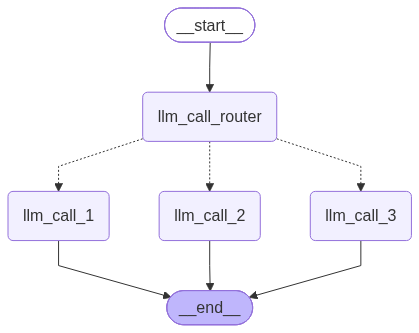

Why did the cat join a band?

Because he wanted to be the **purr**cussionist!

In [9]:
# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
show_graph(router_workflow)

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
rprint(state["output"])

### Functional API

`Route` schema 与 `router` 已在上文 Graph API 中定义, 此处直接复用。

In [10]:
@task
def llm_call_1(input_: str):
    """Write a story"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_2(input_: str):
    """Write a joke"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_3(input_: str):
    """Write a poem"""
    result = llm.invoke(input_)
    return result.content


def llm_call_router(input_: str):
    """Route the input to the appropriate node"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=input_),
        ]
    )
    return decision.step


# Create workflow
@entrypoint()
def router_workflow(input_: str):
    next_step = llm_call_router(input_)
    if next_step == "story":
        llm_call = llm_call_1
    elif next_step == "joke":
        llm_call = llm_call_2
    elif next_step == "poem":
        llm_call = llm_call_3

    return llm_call(input_).result()

# Invoke
stream = router_workflow.stream_events("Write me a joke about cats", version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

[
    {
        'type': 'text',
        'text': 'Why did the cat join a band?\n\nBecause he wanted to be the **purr**cussionist!',
        'index': 0
    }
]

## Orchestrator-worker

在 orchestrator-worker 配置中, orchestrator 会:

- 把任务拆解成子任务
- 把子任务分派给 workers
- 汇总各 worker 的输出, 形成最终结果

![worker.png](https://docs.langchain.com/oss/images/worker.png)

Orchestrator-worker workflow 灵活性更高, 常用于子任务无法像[并行化](#parallelization)那样预先定义的情况。这在写代码或需要跨多个文件更新内容的 workflow 中很常见。例如, 一个需要在数量未知的文档中更新多个 Python 库安装说明的 workflow, 就可能采用这种模式。

### Graph API

In [11]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

### Functional API

`Section`、`Sections` 与 `planner` 已在上文 Graph API 中定义, 此处直接复用。

In [12]:
@task
def orchestrator(topic: str):
    """Orchestrator that generates a plan for the report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {topic}"),
        ]
    )

    return report_sections.sections


@task
def llm_call(section: Section):
    """Worker writes a section of the report"""

    # Generate section
    result = llm.invoke(
        [
            SystemMessage(content="Write a report section."),
            HumanMessage(
                content=f"Here is the section name: {section.name} and description: {section.description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return result.content


@task
def synthesizer(completed_sections: list[str]):
    """Synthesize full report from sections"""
    final_report = "\n\n---\n\n".join(completed_sections)
    return final_report


@entrypoint()
def orchestrator_worker(topic: str):
    sections = orchestrator(topic).result()
    section_futures = [llm_call(section) for section in sections]
    final_report = synthesizer(
        [section_fut.result() for section_fut in section_futures]
    ).result()
    return final_report

# Invoke
report = orchestrator_worker.invoke("Create a report on LLM scaling laws")
Markdown(report)

# Introduction and Historical Context

## Defining Scaling Laws

Scaling laws are empirical relationships that describe how the performance of a machine learning model changes as a function of scale—typically measured in model parameters, training dataset size, and compute budget. In the context of large language models (LLMs), these laws take the form of power-law relationships: as one or more scaling variables increase, a model's loss (usually measured as cross-entropy on a held-out dataset) decreases predictably, following a curve that is remarkably smooth and consistent across many orders of magnitude.

Formally, a scaling law might express test loss \( L \) as:

\[
L(N, D, C) \approx f(N, D, C)
\]

where \( N \) is the number of model parameters, \( D \) is the number of training tokens, and \( C \) is the total compute (often approximated as \( C \approx 6ND \) for transformer-based models). The key insight is that these relationships are not merely qualitative—they are quantitative, allowing researchers to extrapolate performance from small-scale experiments to much larger, more expensive training runs.

## The Historical Arc

### Early Empirical Observations: Kaplan et al. (2020)

The modern era of scaling laws for LLMs began with the seminal work of Kaplan et al. (2020), "Scaling Laws for Neural Language Models." Using transformers trained on a large corpus of web text, the authors demonstrated that test loss follows a power law in model size, dataset size, and compute, with each factor exhibiting its own exponent. Crucially, they found that performance depends strongly on scale and only weakly on architectural details such as depth, width, and attention head count—provided the model is sufficiently large.

Kaplan et al. also proposed a specific prescription for compute-optimal training: when increasing compute, one should prioritize increasing model size over dataset size. Their analysis suggested that for a fixed compute budget, models should be trained on relatively modest amounts of data and then scaled up in parameters. This conclusion shaped early large-scale efforts, including GPT-3, which was trained on roughly 300 billion tokens with 175 billion parameters.

### The Chinchilla Correction: Hoffmann et al. (2022)

Two years later, Hoffmann et al. (2022) at DeepMind revisited the scaling question with a more systematic experimental design. Their work, often referred to as the "Chinchilla" paper, trained over 400 models ranging from 70 million to 16 billion parameters on 5 billion to 500 billion tokens. The results contradicted Kaplan et al.'s compute-optimal prescription: for a given compute budget, model size and training tokens should be scaled in roughly equal proportions. Specifically, the optimal number of training tokens should be approximately 20 times the number of parameters.

This correction had immediate and profound implications. Many existing large models—including GPT-3, Jurassic-1, and Gopher—were significantly undertrained relative to their size. Chinchilla itself, a 70-billion-parameter model trained on 1.4 trillion tokens, outperformed much larger models such as Gopher (280B) and GPT-3 (175B) on a wide range of benchmarks. The message was clear: data efficiency matters as much as parameter count, and the field had been misallocating compute.

### Current Practice and Refinements

Since Chinchilla, scaling laws have become more nuanced. Subsequent work has explored:

- **Data-constrained scaling**: When high-quality data is limited, laws must account for diminishing returns and the risk of overfitting.
- **Mixture-of-Experts (MoE)**: Sparse models change the relationship between parameters, compute, and performance, requiring modified scaling laws.
- **Inference-aware scaling**: As inference costs grow, some researchers argue for "over-training" smaller models on more data to reduce serving costs, even if it deviates from compute-optimal training.
- **Emergent abilities**: Certain capabilities appear only beyond specific scale thresholds, complicating smooth power-law extrapolation.

Current practice often involves fitting scaling laws to small-scale runs, then using them to predict the performance of a target model before committing to a full training run. This has become standard in industrial labs, where a single training run can cost tens of millions of dollars.

## Why Scaling Laws Matter

Scaling laws are not merely academic curiosities; they have become central to the economics and strategy of LLM development for three reasons.

First, **they enable prediction before training**. By training a series of smaller models and fitting a power law, researchers can estimate the performance of a much larger model without actually training it. This reduces risk and allows for informed go/no-go decisions.

Second, **they guide compute allocation**. Given a fixed budget, scaling laws tell you how to split resources between model size, data, and training time. The Chinchilla correction, for example, led many labs to reallocate resources toward more data and longer training rather than simply larger models.

Third, **they inform billion-dollar infrastructure decisions**. Decisions about how many GPUs to purchase, how to design data centers, and how to plan multi-year research roadmaps all depend on projections of how performance will improve with scale. Scaling laws provide the quantitative backbone for these projections, turning what would otherwise be guesswork into a disciplined engineering practice.

In short, scaling laws have transformed LLM development from an art into a predictive science—one that continues to evolve as models grow larger, data becomes more constrained, and the field confronts the limits of current scaling paradigms.

---

# Foundational Scaling Laws: Kaplan et al. (2020)

## Overview and Context

In January 2020, Jared Kaplan, Sam McCandlish, Tom Henighan, Tom B. Brown, Benjamin Chess, Rewon Child, Scott Gray, Alec Radford, Jeffrey Wu, and Dario Amodei—then at OpenAI—published *"Scaling Laws for Neural Language Models"* (arXiv:2001.08361). This paper was the first systematic, quantitative characterization of how transformer language model performance improves as a function of scale, and it fundamentally reframed how the field thought about model development: rather than treating architecture and hyperparameter tuning as the primary levers of progress, Kaplan et al. argued that **scale itself—parameters, data, and compute—is the dominant, predictable driver of performance**, and that this relationship follows clean power laws spanning many orders of magnitude.

The work predates and directly motivated the GPT-3 effort, and it established the empirical and methodological template that subsequent scaling work (most notably Hoffmann et al., 2022, the "Chinchilla" paper) would refine and partially revise.

## Methodology

The central methodological innovation was **large-scale, controlled extrapolation**. The authors trained over a thousand transformer language models on a large web corpus (WebText2), varying:

- **Model size** \(N\): from roughly \(10^3\) to \(10^9\) non-embedding parameters (768K to 1.5B in the headline runs).
- **Dataset size** \(D\): from \(2^3\) to \(2^{12}\) tokens (later extended to ~23B tokens).
- **Compute budget** \(C\): derived as \(C \approx 6ND\) (a standard estimate for transformer training FLOPs, where the factor 6 accounts for forward and backward passes).
- **Architecture and hyperparameters**: depth, width, attention heads, batch size, learning rate schedule, and context length were varied to isolate their effects.

The procedure was:

1. **Train many models across scales**, holding other factors fixed where possible.
2. **Fit power laws** of the form \(L = \alpha X^{-\beta}\) (or with an irreducible-loss offset) to the resulting loss curves.
3. **Test extrapolation**: fit on smaller models and predict the loss of larger ones, then verify. The fits held to within a few percent across multiple orders of magnitude, which was the paper's most striking claim—performance at scale is *predictable* from small-scale runs.

Loss was measured as cross-entropy on held-out text, and the authors emphasized that this smooth, monotonic quantity is far more informative than discrete downstream metrics, which can be noisy and non-monotonic.

## The Power-Law Relationships

The paper's core results are a set of power laws relating test loss \(L\) to each scale variable, when the others are not bottlenecks.

### 1. Loss vs. model size (parameters)

When data and compute are not limiting (i.e., training on sufficiently large datasets, with early stopping at convergence), loss depends on the number of non-embedding parameters \(N\) as:

\[
L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}, \quad \alpha_N \approx 0.076
\]

Equivalently, \(L \propto N^{-0.076}\). The exponent is small: loss improves slowly but *reliably* with parameter count. The authors noted that embedding parameters and non-embedding parameters scale differently, and that performance depends primarily on non-embedding parameters.

### 2. Loss vs. dataset size (tokens)

When model size is not limiting (i.e., a large model trained on varying amounts of data), loss depends on the number of training tokens \(D\) as:

\[
L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}, \quad \alpha_D \approx 0.095
\]

So \(L \propto D^{-0.095}\). Again a small exponent, but slightly larger than the parameter exponent—meaning, in this regime, doubling data yields a somewhat larger loss reduction than doubling parameters.

### 3. Loss vs. compute budget

When both \(N\) and \(D\) are jointly optimized under a fixed compute budget \(C\), the authors found:

\[
L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}, \quad \alpha_C \approx 0.050
\]

with \(C \approx 6ND\). The exponent \(\alpha_C \approx 0.05\) is the smallest of the three, reflecting that compute buys improvements through *both* parameters and data, but with diminishing returns.

### 4. Combined functional form

The authors proposed a unified form combining all three dependencies:

\[
L(N, D) = \left[\left(\frac{N_c}{N}\right)^{\alpha_N/\alpha_D} + \frac{D_c}{D}\right]^{\alpha_D}
\]

This captures the transition between a **data-limited regime** (small \(D\), where loss is dominated by the \(D_c/D\) term) and a **model-limited regime** (large \(D\), where the \(N_c/N\) term dominates). The exponents \(\alpha_N \approx 0.076\) and \(\alpha_D \approx 0.095\) imply that, in the combined form, the parameter term enters with exponent \(\alpha_N/\alpha_D \approx 0.8\).

## The "Model Size Matters More Than Data" Finding

Perhaps the paper's most consequential—and later most contested—claim concerned the **optimal allocation of a fixed compute budget** between parameters and data.

Under the constraint \(C \approx 6ND\), the authors derived that the optimal model size and dataset size scale as:

\[
N_{\text{opt}} \propto C^{\alpha_C/\alpha_N}, \quad D_{\text{opt}} \propto C^{\alpha_C/\alpha_D}
\]

Plugging in the fitted exponents (\(\alpha_C \approx 0.050\), \(\alpha_N \approx 0.076\), \(\alpha_D \approx 0.095\)) gives:

\[
N_{\text{opt}} \propto C^{0.66}, \quad D_{\text{opt}} \propto C^{0.53}
\]

Since \(0.66 > 0.53\), **model size should grow faster than dataset size as compute increases**. The authors concluded that, for a fixed compute budget, it is more efficient to train a *larger model on less data* than a smaller model on more data—and that very large models are substantially *under-trained* relative to their capacity. They explicitly recommended scaling up parameters aggressively and stopping training well before convergence on the available data.

This conclusion had immediate practical impact: it justified the GPT-3 design (175B parameters trained on ~300B tokens, a ratio far more parameter-heavy than later work would endorse) and encouraged the field to prioritize parameter count.

## The "Large Models Are More Sample-Efficient" Claim

A related and equally influential finding was that **larger models are more sample-efficient**: they reach a given loss level with fewer training tokens (and fewer optimization steps) than smaller models. The authors observed that the number of samples required to reach a target loss decreases as a power law in model size, and that larger models also converge in fewer gradient steps.

This claim reinforced the "bigger is better" narrative: not only do large models achieve lower loss, they do so *more efficiently per token*, which—combined with the optimal-allocation result—suggested that scaling parameters was the highest-leverage intervention available.

## Specific Exponents and Functional Forms (Summary)

| Relationship | Functional form | Exponent |
|---|---|---|
| Loss vs. parameters (data-unlimited) | \(L \propto N^{-\alpha_N}\) | \(\alpha_N \approx 0.076\) |
| Loss vs. data (model-unlimited) | \(L \propto D^{-\alpha_D}\) | \(\alpha_D \approx 0.095\) |
| Loss vs. compute (jointly optimized) | \(L \propto C^{-\alpha_C}\) | \(\alpha_C \approx 0.050\) |
| Combined | \(L(N,D) = [(N_c/N)^{\alpha_N/\alpha_D} + D_c/D]^{\alpha_D}\) | — |
| Optimal \(N\) under fixed \(C\) | \(N_{\text{opt}} \propto C^{0.66}\) | — |
| Optimal \(D\) under fixed \(C\) | \(D_{\text{opt}} \propto C^{0.53}\) | — |

The authors also reported that these laws were **remarkably robust to architectural and hyperparameter choices**: depth vs. width, number of attention heads, feed-forward ratio, and even (within limits) learning rate and batch size had far smaller effects than \(N\), \(D\), and \(C\). This robustness was itself a key finding—it suggested that the field's emphasis on architecture search was misallocated relative to scale.

## Extrapolation and Its Significance

The paper's methodological punchline was that these power laws **extrapolate**. Fits performed on models up to ~1B parameters predicted the loss of models an order of magnitude larger to within a few percent. This transformed scaling from an empirical curiosity into a **planning tool**: one could estimate the performance of a future, much larger model from a series of smaller, cheaper runs, and thereby decide whether a given scale-up was worth the compute.

The authors also extrapolated to the then-hypothetical regime of \(10^{12}\)+ parameters, predicting continued loss improvement—a prediction that GPT-3 and subsequent models broadly validated, even as the precise exponents and optimal-allocation conclusions were later revised.

## Legacy and Subsequent Revision

Kaplan et al. (2020) established the conceptual and empirical foundation for the scaling paradigm. However, its central practical recommendation—that parameters should scale faster than data—was **directly challenged** by Hoffmann et al. (2022, "Chinchilla"), who, using a cleaner methodology (isoFLOP profiles rather than fixing \(D\) and varying \(N\)), found that parameters and data should scale **roughly equally** (\(N_{\text{opt}} \propto C^{0.5}\), \(D_{\text{opt}} \propto C^{0.5}\)), implying that GPT-3-class models were significantly *over-parameterized and under-trained*. The Chinchilla result is now widely regarded as the corrected version of the Kaplan optimal-allocation finding, though the broader power-law framework and the sample-efficiency claim remain foundational.

The enduring contributions of Kaplan et al. are therefore: (1) the demonstration that language model loss follows clean, extrapolable power laws in \(N\), \(D\), and \(C\); (2) the methodology of fitting these laws from multi-scale training runs; and (3) the framing of scaling as a predictable engineering discipline rather than an empirical art—a framing that shaped the entire subsequent trajectory of large language model development.

---

# The Chinchilla Correction: Hoffmann et al. (2022)

## Overview

In March 2022, a DeepMind team led by Jordan Hoffmann published *"Training Compute-Optimal Large Language Models"* (Hoffmann et al., 2022), a study that directly challenged the scaling laws established by Kaplan et al. (2020) and fundamentally redirected how the field thought about allocating compute between model size and training data. The paper's central claim was deceptively simple: for a fixed compute budget, model parameters and training tokens should be scaled in roughly equal proportion—approximately **20 tokens per parameter**—rather than the heavily model-size-biased allocation implied by earlier work. The resulting model, **Chinchilla (70B parameters)**, outperformed far larger contemporaries including **Gopher (280B)** and **GPT-3 (175B)** across a wide range of benchmarks, demonstrating that most large models of the era were substantially *undertrained*.

## The Compute-Optimal Frontier

The core contribution of Hoffmann et al. was a re-derivation of the compute-optimal frontier. Given a fixed computational budget \( C \), approximated as \( C \approx 6ND \) (where \( N \) is the number of parameters and \( D \) the number of training tokens), the question is how to split \( C \) between \( N \) and \( D \). Kaplan et al. had concluded that \( N \) should grow much faster than \( D \)—roughly \( N \propto C^{0.73} \) and \( D \propto C^{0.27} \)—implying that under a 10× compute increase, model size should grow by about 5.5× while data grew only ~1.8×.

Hoffmann et al. found the opposite balance. Their fits yielded approximately:

- \( N_{opt} \propto C^{0.50} \)
- \( D_{opt} \propto C^{0.50} \)

In other words, **parameters and tokens should scale in equal proportion** as compute grows. This translates to a practical heuristic of roughly **20 training tokens per parameter** at the compute-optimal point. The paper offered three independent estimation methods—training curves across fixed model sizes, IsoFLOP profiles, and parametric loss fitting—all converging on this conclusion.

## Methodological Improvements

The discrepancy with Kaplan et al. was not merely a matter of interpretation; it stemmed from concrete methodological differences that the Chinchilla authors identified and corrected:

1. **Learning rate schedules matched to token counts.** Kaplan et al. trained models with a fixed cosine learning rate schedule, which meant that models trained on fewer tokens (relative to their size) were effectively evaluated mid-schedule, biasing results toward larger models. Hoffmann et al. adjusted the schedule length to match the number of tokens seen, ensuring each run completed its decay. This alone accounted for a substantial portion of the shift in the frontier.

2. **More rigorous fitting across many runs.** The Chinchilla study trained over **400 models** ranging from 70M to 16B parameters and 5B to 500B tokens, fitting loss surfaces using three complementary approaches (IsoFLOP curves, iso-token curves, and a parametric loss model \( L(N, D) = E + A/N^\alpha + B/D^\beta \)). This density of data points allowed a more reliable estimate of the joint optimum than the sparser grid used previously.

3. **Consistent evaluation protocol.** All models were evaluated on the same held-out set of downstream tasks, avoiding confounds from differing tokenizers or evaluation setups.

These corrections did not merely refine the earlier numbers—they inverted the recommended allocation.

## Quantifying the Impact

The headline result was the Chinchilla model itself: **70B parameters trained on 1.4 trillion tokens**. Despite being roughly **4× smaller than Gopher (280B)** and **2.5× smaller than GPT-3 (175B)**, Chinchilla achieved:

- **67.5%** average accuracy across MMLU, compared to Gopher's 60.0% and GPT-3's 43.9%.
- State-of-the-art results on **MMLU, BIG-bench, RACE, and other benchmarks**, often by large margins.
- Superior performance on reading comprehension, commonsense reasoning, and closed-book QA.

Crucially, Chinchilla was *cheaper to train and cheaper to serve* than the models it beat. The implication was stark: the field had been spending compute on parameters when it should have been spending it on data.

## Reshaping Industry Practice

The Chinchilla correction triggered a rapid reorientation of large-model development:

- **Data-heavy training became the norm.** Models released after 2022—LLaMA (2023), which trained a 7B model on 1T tokens (~140 tokens/parameter), and its successors—explicitly cited Chinchilla as justification for training smaller models on far more data than previously considered necessary.
- **"Chinchilla-optimal" entered the lexicon** as shorthand for the 20:1 token-to-parameter ratio, though subsequent work (e.g., LLaMA, and later "over-training" studies) showed that for inference-constrained deployments, training *beyond* Chinchilla-optimal on even more tokens can be economically rational.
- **Compute budgets were reallocated.** Organizations that had planned trillion-parameter models pivoted to training 10–70B models on multi-trillion-token corpora, improving both capability and serving economics.
- **Data curation and acquisition became strategic priorities**, since the new frontier made high-quality tokens the binding constraint rather than parameter count.

In retrospect, the Chinchilla paper is best understood not as a refutation of scaling laws but as a correction to their *coefficients*. Scaling still worked—but the optimal recipe was different, and the field's prior allocation of compute had been systematically misaligned with it. The correction reshaped both the theory and the practice of large language model training within months of publication.

---

# Mathematical Formulation and Functional Forms

## Core Scaling Equations

The empirical scaling behavior of neural language models is captured by power-law relationships between loss and the two primary resource axes: model size and dataset size. The foundational single-variable forms are:

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}$$

$$L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}$$

where $N$ denotes the number of non-embedding parameters, $D$ denotes the number of training tokens, and $\alpha_N, \alpha_D > 0$ are the scaling exponents. These forms express the intuitive notion that loss decreases as a power law as either resource is increased, with diminishing returns governed by the exponent magnitude.

The combined, two-variable form—often called the *parametric loss model*—decomposes total loss into an irreducible floor plus separable power-law corrections:

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

Here $E$ is the **irreducible loss** (also called the entropy floor or Bayes-error term): the lowest achievable loss for the data distribution, independent of model capacity or data volume. $A$ and $B$ are fitted constants absorbing the scale of each term, while $\alpha$ and $\beta$ are the model- and data-scaling exponents respectively. The separability assumption—that the $N$- and $D$-dependent terms add rather than interact multiplicatively—is a modeling choice that holds approximately over the empirically observed range but is not theoretically guaranteed.

## Interpretation of Parameters

**Irreducible loss $E$.** This term represents the intrinsic uncertainty of the data-generating process. It cannot be reduced by scaling either axis and serves as the asymptote of the loss curve. Empirically, $E$ is estimated jointly with the other parameters and typically lands near the entropy of natural text under the tokenizer.

**Critical sizes $N_c$ and $D_c$.** In the single-variable forms, $N_c$ and $D_c$ are the resource levels at which loss equals unity (or, in normalized variants, the crossover scales where the power-law term equals the irreducible floor). They set the *units* of the scaling law and are not themselves fundamental constants—they depend on the tokenizer, architecture family, and data distribution. Their practical role is to anchor the curve so that exponents are dimensionless and comparable across settings.

**Exponents $\alpha$ and $\beta$.** These govern the *rate* of diminishing returns. A larger $\alpha$ means model capacity buys loss reduction quickly; a smaller $\alpha$ means returns saturate sooner. Typical fitted values for transformer language models fall in the range $\alpha \approx 0.3$–$0.5$ and $\beta \approx 0.3$–$0.5$, though exact values depend on architecture, optimizer, and data. The exponents are the quantities that determine optimal allocation, so their estimation is the central empirical task.

## Compute-Optimal Allocation

Given a fixed compute budget $C$, the training cost is approximated as $C \approx 6ND$ (forward and backward FLOPs per parameter per token, with the factor 6 being the standard convention). Minimizing $L(N,D)$ subject to $6ND = C$ yields the optimal allocation.

Substituting $D = C/(6N)$ into the loss and differentiating with respect to $N$:

$$\frac{\partial L}{\partial N} = -\frac{\alpha A}{N^{\alpha+1}} + \frac{\beta B}{D^{\beta+1}} \cdot \frac{\partial D}{\partial N} = 0$$

With $\partial D/\partial N = -C/(6N^2) = -D/N$, this gives the balance condition:

$$\alpha A N^{-\alpha} = \beta B D^{-\beta}$$

Solving alongside the compute constraint produces power-law optima:

$$N_{\text{opt}} \propto C^{a}, \qquad D_{\text{opt}} \propto C^{b}, \qquad a + b = 1$$

where the exponents are determined by the fitted scaling parameters:

$$a = \frac{\beta}{\alpha + \beta}, \qquad b = \frac{\alpha}{\alpha + \beta}$$

The constraint $a + b = 1$ reflects that compute is exhausted by the product $ND$: doubling compute must be split between the two axes, and the split is dictated by the relative exponents. If $\alpha = \beta$, the optimal strategy is to scale $N$ and $D$ in equal proportion ($a = b = 0.5$). If $\alpha > \beta$ (model scaling is more efficient), then $b > a$ and more compute should go to data; conversely, if data scaling is more efficient, more compute goes to parameters. This derivation is the analytical core of compute-optimal training and directly motivates the Chinchilla-style prescriptions.

## Fitting Procedure

The parameters $\{E, A, B, \alpha, \beta\}$ are estimated by fitting the combined form to a grid of training runs spanning multiple $(N, D)$ pairs. The standard procedure is:

1. **Data collection.** Train models across a log-spaced grid of sizes and token budgets, recording final loss at each point. Runs that are compute-inefficient (e.g., heavily over-trained small models or under-trained large models) are retained because they constrain the shape of the surface.

2. **Objective.** Minimize a robust loss between predicted and observed loss. **Huber loss** is preferred over squared error because it down-weights outliers from unstable runs (divergences, learning-rate sensitivity) while retaining quadratic behavior near the optimum. The Huber threshold is typically set relative to the noise floor of the training runs.

3. **Optimizer.** **L-BFGS** is the standard choice: the problem is low-dimensional (5–7 parameters), smooth, and admits cheap gradients, so quasi-Newton methods converge quickly and reliably. Some studies use multi-start L-BFGS or grid initialization over exponent ranges to avoid poor local minima.

4. **Parametric fits and constraints.** Fits are often performed in log-space or with reparameterization (e.g., fitting $\log A$, $\log B$) to enforce positivity of $A, B, \alpha, \beta$ and $E$. Envelope methods—fitting lower envelopes of loss curves across learning-rate sweeps—are used to isolate the scaling behavior from optimization noise.

## Limitations

Several caveats bound the validity of these forms:

- **Separability.** The additive decomposition $E + A/N^\alpha + B/D^\beta$ assumes no interaction between model and data scaling. In practice, interactions exist: very small models saturate on large datasets differently than the additive form predicts, and the exponents can drift when the $(N, D)$ grid is unbalanced.

- **Regime dependence.** Exponents fitted in one compute regime (e.g., $10^{18}$–$10^{21}$ FLOPs) need not extrapolate to another. There is evidence of exponent changes at very large scales, and the irreducible loss $E$ is itself an extrapolated quantity that may not be identifiable from finite data.

- **Architecture and data specificity.** $N_c$, $D_c$, and the exponents are not universal constants; they shift with tokenizer, architecture (dense vs. mixture-of-experts), data quality and mixture, and optimizer. A fit is valid only for the family it was estimated on.

- **Compute model simplification.** $C \approx 6ND$ ignores attention quadratic costs, inference overhead, and the fact that optimal batch size and learning rate themselves scale with $N$ and $D$. The derived $N_{\text{opt}} \propto C^a$ is therefore an approximation whose accuracy depends on the training recipe being near-optimal at each grid point.

- **Loss vs. downstream metrics.** The laws are formulated for cross-entropy loss. Downstream task performance does not always track loss monotonically, so compute-optimal allocation for loss may not be optimal for a specific benchmark.

These limitations motivate treating the scaling law as a *local* guide for allocation rather than a universal law, and they explain why subsequent work refines the functional form (e.g., adding interaction terms or fitting separate exponents per regime) while retaining the core power-law structure.

---

# Beyond the Basics: Emergent Abilities and Their Critics

## The Original Claim: Sharp Discontinuities at Scale

The modern debate over emergent abilities begins with Wei et al. (2022), who analyzed performance trajectories across model families spanning several orders of magnitude of compute (roughly \(10^{19}\) to \(10^{23}\) FLOPs) on a suite of few-shot prompting benchmarks. Their central empirical claim was that certain capabilities are **absent in smaller models and present in larger ones**, with the transition occurring over a narrow range of scale rather than as a gradual incline. They termed these *emergent abilities*: "abilities that are not present in smaller-scale models but are present in larger-scale models; thus they cannot be predicted by simply extrapolating the performance improvements on smaller-scale models."

The canonical examples were striking. On arithmetic tasks such as three-digit multiplication, accuracy hovered near zero across many model sizes and then jumped sharply—in some cases from near-chance to above 50%—within a single doubling of scale. Similar step-like curves appeared on multi-step reasoning benchmarks (e.g., chain-of-thought prompting on GSM8K), instruction following, and certain symbolic manipulation tasks. Wei et al. also emphasized that emergence was **task- and prompting-dependent**: a capability might appear abruptly under few-shot prompting but not under zero-shot, suggesting that the phenomenon reflected an interaction between scale and evaluation protocol, not scale alone.

The theoretical interpretation was that emergence poses a fundamental challenge to scaling laws. If capability gains are smooth and predictable (Kaplan et al. 2020; Hoffmann et al. 2022), then smaller runs can forecast larger ones. But if some abilities appear only past a threshold, then extrapolation from small models systematically understates—or entirely misses—what larger models will do. Emergence thus became a headline argument that scale delivers qualitative, not merely quantitative, change.

## The Counterargument: Emergence as a Measurement Artifact

Schaeffer et al. (2023) challenged this interpretation directly, arguing that "emergence is a mirage" produced by the choice of metric rather than by any discontinuity in the underlying model behavior. Their argument has two parts.

First, a **conceptual distinction** between *emergent abilities* and *emergent metrics*. A capability is a property of the model; a metric is a function applied to its outputs. Schaeffer et al. contend that the sharp jumps documented by Wei et al. are properties of the metrics—typically **discontinuous, threshold-based measures** such as exact-match accuracy, multiple-choice accuracy, or pass/fail on a whole task. These metrics assign zero credit to partially correct or nearly correct outputs. A model that produces the right answer on 1% of items and one that produces it on 40% can both score near zero on exact match if the scoring requires full correctness, and the transition from "almost never" to "sometimes" can look like a cliff when the metric only registers all-or-nothing success.

Second, an **empirical demonstration**. When Schaeffer et al. replaced discontinuous metrics with continuous ones—token-level edit distance, BLEU, or the probability the model assigns to the correct answer—the same model families and tasks produced smooth, gradually rising curves. The apparent discontinuity vanished. They further showed that the location of the "jump" is sensitive to arbitrary choices: changing the number of few-shot examples, the scoring threshold, or the resolution of the evaluation grid can move or eliminate the perceived emergence point. On this view, emergence is not a property of scaling but of how researchers operationalize capability.

The rebuttal does not deny that large models can do things small models cannot. It denies that the *transition* is discontinuous in the underlying competence. A model may cross a usability threshold—where outputs become reliably correct enough to be useful—without any discontinuity in the probability of correct behavior.

## Implications for Scaling Laws

The two positions carry different consequences for the validity of scaling laws.

If emergence is real, scaling laws fit on small models are **locally valid but globally misleading**: they describe a regime that does not contain the capabilities of interest, and no amount of small-scale data can predict when a new ability will appear. This would justify treating certain capabilities as qualitatively new and would undermine confident extrapolation from cheap runs to frontier models.

If emergence is a metric artifact, scaling laws retain much more force. The underlying relationship between loss (or continuous task performance) and compute remains smooth and predictable; what changes is only where a discontinuous *evaluation* crosses its threshold. On this reading, the practical lesson is not that scaling laws fail but that they must be paired with metrics capable of resolving gradual improvement. The "emergence" literature then becomes a cautionary tale about measurement, not a refutation of predictability.

A middle position, increasingly common, holds that both can be true: continuous metrics reveal smooth underlying improvement, while discontinuous metrics capture real, decision-relevant thresholds—the points at which a capability becomes reliable enough to deploy. The disagreement is partly about what "ability" means: a latent competence (continuous) or a usable skill (thresholded).

## Implications for Measuring Capability

The debate has concrete methodological consequences.

- **Metric choice is a substantive scientific decision, not a formatting detail.** Exact match, pass@k, and thresholded accuracy impose discontinuities that can manufacture or mask trends. Reporting continuous metrics alongside them is now widely recommended.
- **Evaluation resolution matters.** Coarse model-size grids can make a gradual rise look like a jump; finer grids often reveal intermediate performance.
- **Prompting and task framing interact with scale.** Because emergence was documented under specific few-shot regimes, claims about a capability should specify the protocol under which it was measured.
- **"Emergent" should be treated as a claim about a metric, not a model.** The Schaeffer et al. critique suggests reserving the term for cases where discontinuities survive continuous measurement—if any do.

The unresolved question is whether any capabilities remain genuinely discontinuous once measured carefully. Proponents of emergence point to qualitative shifts—chain-of-thought reasoning, in-context learning, instruction following—that seem to involve new behavioral repertoires rather than better sampling from an existing one. Critics respond that these too may resolve into smooth curves under the right metric, and that the burden of proof now lies with those claiming discontinuity. Either way, the exchange has reshaped how the field reports scaling results: continuous metrics, explicit protocols, and skepticism toward threshold-based claims are now baseline expectations rather than optional refinements.

---

# Extensions and Modern Refinements

The Chinchilla scaling laws established a compute-optimal frontier for training dense transformer language models under a fixed data distribution. However, the rapid evolution of the field since 2022 has exposed several limitations of the original framework and motivated a rich body of follow-up work. This section surveys the principal extensions and refinements, organized around five themes: (i) scaling under data constraints, (ii) architectural scaling via mixture-of-experts, (iii) inference-aware and inference-optimal scaling, (iv) scaling laws for fine-tuning and alignment, and (v) scaling laws for downstream performance and reasoning, including test-time compute.

## 1. Data-Constrained Scaling Laws

The Chinchilla analysis assumes that the training corpus can be scaled arbitrarily with the model. In practice, high-quality web text is finite, and frontier models are increasingly trained on datasets that are reused across multiple epochs. Muennighoff et al. (2023) formalized this regime by introducing **data-constrained scaling laws**. Their central finding is that repeating data yields **diminishing returns**: up to roughly four epochs, repeated tokens are nearly as valuable as fresh tokens, but beyond this point the marginal value of an additional epoch decays toward zero. They model this with an effective-data term that saturates as a function of the number of repetitions, allowing the Chinchilla functional form to be recovered in the limit of unlimited unique data. A key practical implication is that in a data-constrained regime, the compute-optimal allocation shifts toward *smaller* models trained for *more* epochs than the Chinchilla prescription would suggest, because additional parameters cannot be productively matched with additional unique data.

Related work has examined the interaction between data repetition and model size, showing that larger models benefit less from repeated data and that the penalty for repetition grows with model scale. Other studies have explored data quality filtering, deduplication, and synthetic data as partial substitutes for fresh tokens, though the scaling behavior of synthetic data remains an active area of investigation.

## 2. Mixture-of-Experts Scaling

Mixture-of-experts (MoE) architectures decouple total parameter count from per-token compute by activating only a subset of parameters for each input. This breaks a core assumption of the Chinchilla laws, which equate parameters with compute. Clark et al. (2022) provided an early scaling study for MoE language models, showing that MoE models follow power laws in both training compute and model size, but with different exponents than dense models, and that they can achieve lower loss at a given compute budget when the number of experts is scaled appropriately. Subsequent work has refined these laws by accounting for the number of active parameters, the total parameter count, the routing mechanism, and the expert granularity. A recurring finding is that **active parameters** are the more relevant variable for predicting loss at fixed compute, while total parameters govern capacity and memory. This has made MoE a central tool for inference-efficient scaling, and modern frontier models frequently adopt sparse architectures for this reason.

## 3. Inference-Aware and Inference-Optimal Scaling

Chinchilla optimizes only training compute. In deployment, inference cost often dominates the total cost of ownership, which has motivated **inference-aware scaling laws**. Sardana et al. (2024) and related work introduce a two-dimensional optimization over model size and training tokens that explicitly accounts for the inference budget. The key insight is that when inference cost is included, the optimal model is typically *smaller* and trained on *more* tokens than the Chinchilla-optimal point, because smaller models are cheaper to serve. This reframing has direct implications for the practical design of deployed systems and helps explain the trend toward "over-trained" small models (e.g., models trained well beyond the Chinchilla-optimal token count for their size).

A parallel line of work studies **inference-optimal scaling** in the context of test-time compute, discussed further in Section 5.

## 4. Scaling Laws for Fine-Tuning and Alignment

Pretraining scaling laws do not directly predict performance after fine-tuning or alignment. Several works have begun to fill this gap:

- **Fine-tuning scaling.** Hernandez et al. (2021) showed that fine-tuning performance follows a power law in the number of fine-tuning examples, with a transfer-dependent offset that improves as pretraining scale increases. This established that larger pretrained models are more sample-efficient fine-tuners, a result that has been broadly replicated.
- **RLHF scaling.** Work on reinforcement learning from human feedback has examined how reward model quality, policy optimization, and preference data volume scale. While a clean unified law remains elusive, studies have found that RLHF gains tend to saturate with preference data and that reward model accuracy scales predictably with data and model size, providing a partial bridge between alignment compute and downstream behavior.
- **Instruction tuning.** Scaling studies of instruction tuning report diminishing returns from additional instruction data and a strong dependence on data diversity and quality, with model scale modulating how much instruction data is useful.

## 5. Scaling Laws for Downstream Performance and Reasoning

A persistent critique of Chinchilla-style laws is that they predict **perplexity**, not task accuracy. Recent work has sought to connect the two:

- **Downstream scaling.** Several studies fit sigmoidal or power-law relationships between pretraining loss (or compute) and downstream benchmark accuracy, finding that accuracy often improves smoothly but with task-specific thresholds and saturation. This has led to the notion of **emergent** capabilities, though subsequent analyses argue that many apparent emergences are artifacts of metric choice and that smooth scaling is more common when measured appropriately.
- **Reasoning and test-time compute.** The most significant recent extension concerns **test-time compute**. OpenAI's o1-style models demonstrate that allocating additional compute at inference—via longer chains of thought, search, or sampling—can substantially improve reasoning performance. Scaling laws for this regime (e.g., Snell et al., 2024) show that test-time compute and model size are partially substitutable: a smaller model given more inference compute can match a larger model given less, up to a point. The optimal allocation depends on the difficulty of the task and the inference budget, and there is evidence that the returns to test-time compute follow their own power-law-like curves. This has reframed scaling as a **two-axis** problem—training compute and inference compute—and motivated the design of models explicitly optimized for extended reasoning.

## Summary

Post-Chinchilla work has substantially generalized the scaling framework. Data-constrained laws account for finite corpora and repeated epochs; MoE laws decouple parameters from compute; inference-aware laws incorporate serving cost; fine-tuning and RLHF studies extend scaling to post-training; and reasoning-focused work introduces test-time compute as a first-class scaling axis. Together, these refinements paint a more complete picture in which the optimal allocation of resources depends not only on training compute but also on data availability, architecture, inference budget, and the target task—moving the field from a single frontier toward a family of task- and deployment-dependent frontiers.

---

# Practical Implications and Industry Practice

Scaling laws began as descriptive curiosities—empirical fits showing that loss falls as a power law in compute, data, and parameters—but they have become the quantitative backbone of how frontier labs plan, budget, and justify training runs. In practice, a scaling law is less a scientific result than an operational tool: a way to convert a fixed compute or dollar budget into a predicted model quality, and to decide *how* to spend that budget before committing millions of dollars of GPU time. This section examines how labs actually use these relationships, the central tension between compute-optimal and inference-optimal training, the outsized role of data quality, and how scaling laws inform the decision to stop training.

## Planning Training Runs and Setting Budgets

The most common industrial use of scaling laws is *ex-ante* planning. Before a run, a team fits a scaling law to a family of smaller runs (often spanning several orders of magnitude in compute) and extrapolates to the target scale. This produces three coupled decisions: model size (parameters), dataset size (tokens), and total compute. The Chinchilla work (Hoffmann et al., 2022) made this concrete by showing that, for a fixed compute budget, loss is minimized when parameters and training tokens are scaled in roughly equal proportion—approximately 20 tokens per parameter. This overturned the earlier Kaplan et al. (2020) guidance, which had suggested spending most of the budget on parameters and comparatively little on data.

The practical consequence was immediate and visible across model families. GPT-3 (175B parameters, ~300B tokens) was trained in the pre-Chinchilla regime, i.e., heavily parameter-rich and data-light by later standards. Meta's Llama family illustrates the shift: Llama 1 (2023) was trained on roughly 1–1.4T tokens, while Llama 2 and especially Llama 3 were trained on far more data per parameter—Llama 3 8B and 70B were trained on ~15T tokens, a token-to-parameter ratio well above the original Chinchilla optimum. Google's Gemini and Anthropic's Claude families are not fully documented publicly, but their reported compute budgets and capability scaling are consistent with the same planning logic: fit a law, pick a target, allocate compute, and reserve a margin for the inevitable surprises.

In practice, labs rarely treat the fitted law as ground truth. They use it as a *prior* and build in safety factors, because extrapolation error grows with scale and because downstream benchmark performance does not always track loss monotonically.

## Compute-Optimal vs. Inference-Optimal Training

The Chinchilla "compute-optimal" point minimizes training loss for a given training compute budget. But training compute is only part of the total cost of a deployed model. Inference cost scales with model size and is incurred every time the model is served—potentially billions of times. This creates a well-known divergence between *training-optimal* and *deployment-optimal* choices.

A smaller model trained on far more tokens than Chinchilla would recommend can achieve comparable loss to a larger, less-trained model, while being dramatically cheaper to serve. This is the "overtraining" regime, and it is now standard practice for models intended for high-volume inference. Llama 3 is the clearest public example: Meta explicitly stated that the 8B and 70B models were trained well beyond compute-optimal because inference cost dominates for their use cases. The same logic drives the proliferation of small, heavily-trained models (e.g., 1–8B parameter models trained on trillions of tokens) designed for on-device or high-throughput serving.

The tradeoff can be framed as a total-cost-of-ownership calculation. If a model will serve \(N\) tokens over its lifetime, the relevant objective is not training loss at fixed training compute, but quality at fixed *training + inference* compute. As \(N\) grows, the optimal model shrinks and the optimal training token count grows. Labs therefore maintain separate scaling recipes for "flagship" models (where capability is paramount and inference volume may be lower) and "workhorse" models (where serving economics dominate).

## Data Quality, Curation, and the Limits of Quantity

Scaling laws in their simplest form assume a fixed data distribution. In reality, data quality and curation have first-order effects that can rival or exceed the effects of scale. The practical implications are significant:

- **Deduplication and filtering** change the effective dataset size. A deduplicated corpus of 1T tokens may be worth more than a noisy 3T-token corpus, which breaks naive token-count scaling.
- **Data mixture** matters. Labs tune the ratio of web text, code, math, and curated sources, and scaling laws fit on one mixture do not transfer cleanly to another.
- **Repetition and epochs.** When high-quality data is scarce, models are trained for multiple epochs over the same data. Returns diminish with repetition, and scaling laws must be modified to account for this—an active area of research (e.g., Muennighoff et al., 2023).
- **Synthetic and model-generated data** are increasingly used to extend effective dataset size, but their scaling behavior differs from human-generated text.

The practical upshot is that labs treat "data budget" as a multidimensional decision—not just token count, but quality tier, domain mix, and number of epochs. A scaling law that ignores curation will systematically mispredict, which is why frontier labs invest heavily in data pipelines and treat the data recipe as a closely guarded asset.

## Overtraining and the Decision to Stop

Overtraining—training past the compute-optimal point—is now the norm rather than the exception for deployed models. The decision to stop training is therefore not "when loss stops improving" but "when marginal quality gain no longer justifies marginal cost, given the intended deployment."

Several factors inform this decision:

1. **Diminishing returns.** Loss improvements follow a power law, so each additional unit of compute buys less. Labs estimate the marginal cost per unit of loss reduction and compare it to the value of the resulting capability.
2. **Inference economics.** As discussed, a model that will be served at high volume may be trained far past the point that would be optimal if training cost were the only consideration.
3. **Downstream evaluation.** Loss is a proxy. Labs monitor benchmark performance and often stop when target capabilities are reached, even if loss could still fall.
4. **Data exhaustion.** When the high-quality token budget is exhausted, further training requires repetition or lower-quality data, both of which have worse scaling behavior.
5. **Risk and schedule.** Longer runs carry higher risk of hardware failure, instability, and missed deadlines. Many runs are stopped for operational rather than statistical reasons.

Published model families reflect these judgments. Llama 3's training was explicitly justified by inference-cost considerations. GPT-4's training scale and the subsequent emphasis on smaller, cheaper variants (e.g., GPT-4o mini) reflect the same deployment-driven logic. Gemini's tiered offerings (Ultra, Pro, Flash, Nano) map directly onto different points on the training/inference tradeoff curve. Anthropic's Claude family similarly spans capability and cost tiers, with the smaller models trained to be competitive at serving-friendly sizes.

## Forecasting and Organizational Practice

Beyond individual runs, scaling laws support forecasting: predicting what will be achievable at a future compute budget, and therefore what infrastructure to build and when. This drives multi-year capital planning for data centers, chip procurement, and energy contracts. It also informs research prioritization—if a capability is predicted to emerge at a certain scale, labs can decide whether to chase it directly or wait for scale to deliver it.

In practice, forecasting is done with ensembles of scaling laws fit to different data mixtures, architectures, and evaluation metrics, combined with human judgment. The laws are treated as decision aids, not oracles. The most sophisticated labs maintain internal scaling law teams whose job is to keep these predictions calibrated as architectures (e.g., mixture-of-experts, long-context variants) and data recipes evolve.

## Summary

Scaling laws have moved from academic observation to operational infrastructure. They shape how labs size models, budget data, choose between training-optimal and inference-optimal configurations, and decide when to stop. The dominant practical trend is the shift toward inference-aware training—smaller models trained longer—driven by the economics of serving. Data quality and curation modulate these laws in ways that simple token-count scaling cannot capture, and the decision to stop training is a joint function of diminishing returns, deployment economics, data availability, and operational risk. The published trajectories of GPT, Llama, Gemini, and Claude all reflect these principles, even where the underlying scaling laws remain proprietary.

---

# Limitations, Criticisms, and Open Questions

Scaling laws are among the most empirically robust regularities in modern machine learning, but their predictive power is bounded in ways that are easy to overlook. This section examines the principal limitations of the scaling-law framework, the criticisms leveled against its use as a guide for research and investment, and the open questions that remain unresolved.

## Limitations

**Scaling laws predict loss, not capability.** The most fundamental limitation is one of construct validity: scaling laws are fitted to a surrogate metric—typically cross-entropy loss on a held-out distribution—rather than to the downstream capabilities that motivate training runs in the first place. Loss is a smooth, aggregate quantity; capabilities are often discrete, emergent, and task-specific. A model can improve substantially in loss while showing flat or erratic performance on reasoning, factual recall, or long-horizon planning, and conversely, capability can appear abruptly at scales where loss curves show no inflection. Because the mapping from loss to capability is neither fixed nor well understood, a scaling law that predicts loss to within a few percent may still misestimate the compute required to reach a given level of usefulness by orders of magnitude. Treating loss as a proxy for capability is therefore a modeling assumption, not a measured fact.

**Fitted on specific architectures and data distributions.** Scaling laws are empirical fits, and their parameters absorb the idiosyncrasies of the setting in which they were estimated: the architecture family (e.g., transformer variants), the optimizer and learning-rate schedule, the tokenizer, the data mixture, and the evaluation distribution. Coefficients estimated on one configuration do not automatically transfer to another. Changes that seem minor—a different attention mechanism, a different data-mixing ratio, a different context length—can shift the fitted constants, and in some cases the functional form itself. This means scaling laws are best understood as local approximations valid within a neighborhood of the training regime that produced them, not as universal laws of learning.

**Irreducible loss and data-quality ceilings.** Most fitted laws include an irreducible-loss term, an asymptote that cannot be reduced by adding compute or parameters. This term is not a law of nature; it reflects the intrinsic entropy and noise of the data distribution, including label noise, ambiguity, and genuinely unpredictable content. Its practical consequence is that returns to scale diminish and eventually vanish: beyond some point, additional compute buys negligible loss reduction. A related ceiling comes from data quality. Web-scale corpora contain a long tail of low-quality, duplicated, and toxic material, and the effective size of the high-quality subset is far smaller than the raw token count. When the fitted law assumes a fixed data distribution, it silently assumes that this distribution can be sampled indefinitely—an assumption that fails as training consumes the available high-quality data.

**Extrapolation beyond fitted ranges.** Scaling laws are interpolation devices. They are fitted over a range of model sizes, dataset sizes, and compute budgets, and their predictions are most trustworthy inside that range. Extrapolating to scales far beyond the fitted regime—or to new regimes such as extreme sparsity, very long context, or multimodal training—is an act of faith. The functional forms (power laws, or power laws with exponential decay) are chosen for convenience and fit quality, not derived from theory, and there is no guarantee that the same form holds outside the observed window. History offers cautionary examples: predictions of emergent ability at scale have sometimes failed to materialize, and predictions of saturation have sometimes been overturned by architectural or data changes.

**Compute-optimal is not economically optimal.** The Chinchilla-style prescription—balance parameters and tokens to minimize loss for a fixed compute budget—optimizes a technical objective, not a business one. In practice, the relevant objective is usually cost per unit of capability, subject to constraints on inference latency, memory, throughput, and deployment hardware. A compute-optimal training run may produce a model that is too large or too slow to serve economically, while a smaller model trained past its compute-optimal token count may be cheaper to train and far cheaper to deploy. Inference cost, in particular, often dominates lifetime cost, which pushes the economically optimal point toward smaller models trained on more data—the opposite of what a naive reading of compute-optimal scaling would suggest. Scaling laws also say nothing about data-acquisition cost, annotation cost, or the value of a marginal capability, all of which enter the real decision.

**Tension between scaling and algorithmic efficiency.** Scaling laws describe how loss falls as compute, parameters, and data grow, holding the algorithm fixed. But algorithms change. Architectural innovations, better optimizers, improved data curation, and techniques such as retrieval, tool use, and test-time compute can shift the entire loss curve, effectively buying capability that scaling alone would require far more compute to reach. This creates a tension: a scaling law fitted today may be obsolete tomorrow, not because it was wrong, but because the algorithm it described has been replaced. It also creates a strategic ambiguity—whether to invest in more compute or in better methods—that scaling laws alone cannot resolve, since they quantify the returns to one axis while holding the other fixed.

## Open Questions

**Will scaling continue to hold?** The central open question is whether the observed power-law behavior persists at the next order of magnitude of compute, or whether it bends. Arguments for continuation point to the regularity of the fits across many orders of magnitude and to the fact that no sharp break has yet been observed. Arguments for caution note that the fits are local, that the irreducible-loss term must eventually dominate, and that the most capable systems already combine scaling with substantial algorithmic and data-side intervention, making it difficult to attribute progress to scaling alone. A definitive answer requires training runs at scales that are, by construction, expensive and slow to produce.

**What happens when high-quality data runs out?** If the effective supply of high-quality text is finite, then data—not compute—becomes the binding constraint. Several responses are possible: synthetic data generation, which risks model collapse and distributional narrowing; better filtering and deduplication, which raises the yield from existing corpora; multimodal and embodied data, which opens new sources but also new quality problems; and data-efficient methods such as retrieval, curriculum learning, and few-shot adaptation. How these responses interact with scaling laws is unclear. If synthetic or curated data behaves differently from natural data, the fitted exponents and the irreducible-loss term may change, and the laws may need to be re-estimated on the new distribution.

**How do scaling laws interact with architectural innovation?** Scaling laws and architecture are not independent. A change in architecture can alter the exponents, the irreducible loss, or both, and can change which quantities (parameters, tokens, compute) are the relevant axes. Conversely, scaling can change which architectures are viable: a design that is inefficient at small scale may become competitive at large scale, and vice versa. The open question is whether there is a stable meta-relationship—a way to predict how a given architectural change will shift the scaling curve—or whether each innovation must be characterized empirically from scratch. Without such a relationship, scaling laws remain descriptive of the past rather than predictive of the next design.

**Do capabilities scale smoothly or emergently?** Related to the loss-versus-capability gap is the question of whether capabilities improve smoothly with scale or appear abruptly. If emergence is real and widespread, then loss-based scaling laws are systematically misleading about when a capability will arrive. If apparent emergence is largely an artifact of discontinuous metrics and thresholded evaluations, then smooth loss curves may be a better guide than they appear. Resolving this requires better evaluation methodology as much as better scaling theory.

**What are the limits of transfer across modalities and tasks?** Scaling laws have been most thoroughly studied for language modeling. Whether the same forms, exponents, and irreducible-loss structure apply to vision, audio, multimodal, and embodied settings—and whether a single law can span them—is largely open. Transfer across tasks within a modality is similarly uncertain: a law fitted on average loss may say little about performance on a specific, high-value task.

## Summary

Scaling laws are a powerful but bounded tool. They predict a surrogate metric within a fitted regime, under a fixed algorithm and data distribution, and they say nothing directly about capability, economic optimality, or the value of algorithmic change. Their principal limitations—proxy metrics, narrow validity, irreducible loss, data ceilings, extrapolation risk, and the scaling-versus-efficiency tension—are not defects to be engineered away but boundary conditions to be respected. The open questions—whether scaling continues, what happens when data runs out, and how scaling interacts with architectural innovation—are precisely the questions on which the framework's future usefulness depends, and they are unlikely to be settled by fitting more curves to the same regime.

---

# Conclusion and Future Outlook

## Key Takeaways

The study of scaling laws in artificial intelligence has matured from a collection of empirical curiosities into a central organizing framework for how the field reasons about progress. Several conclusions emerge from the preceding analysis.

**Scaling laws are empirical, predictive, and perpetually provisional.** From Kaplan et al.'s (2020) early power-law fits relating loss to model size, dataset size, and compute, through the Chinchilla revision (Hoffmann et al., 2022), to contemporary inference-aware formulations, the history of scaling laws is one of successive refinement rather than final settlement. Each generation of laws has been genuinely predictive within its regime—enabling practitioners to forecast loss, allocate compute budgets, and set training configurations with surprising accuracy—yet each has also been falsified or superseded as new architectures, objectives, and deployment patterns emerged. This pattern is not a weakness but a defining characteristic: scaling laws are best understood as empirically grounded approximations whose domain of validity must be continuously re-established.

**The Chinchilla correction was pivotal.** The shift from Kaplan-style allocations—which favored ever-larger models trained on comparatively modest data—to Chinchilla-optimal compute allocation, where model size and training tokens scale in roughly equal proportion, fundamentally reshaped industrial practice. It demonstrated that the field had been systematically under-training large models, and it redirected billions of dollars of compute toward data acquisition, curation, and longer training runs. More broadly, Chinchilla established that scaling laws are not merely descriptive but prescriptive: they directly determine how resources should be spent.

**Current frontiers are defined by new constraints and new objectives.** Three developments mark the present state of the art. First, *inference-aware scaling* recognizes that training compute is only part of the cost equation; as models are deployed at scale, the compute expended at inference time—including through chain-of-thought, sampling, and search—becomes a first-class variable in the scaling relationship. Second, *data constraints* have become binding: high-quality text is finite, and the field is increasingly forced to confront data repetition, synthetic data, and curation quality as levers that interact non-trivially with scale. Third, *reasoning models* have introduced a new axis of scaling—test-time compute—that appears to follow its own distinct regularities, potentially decoupling capability gains from parameter count in ways that earlier laws did not anticipate.

## Future Directions

**Multimodal scaling.** The extension of scaling laws beyond text to images, audio, video, and action is among the most consequential open problems. Early evidence suggests that multimodal models exhibit their own scaling behaviors, but the interactions between modality-specific data distributions, encoder architectures, and cross-modal alignment objectives remain poorly characterized. Key questions include whether a unified scaling law can span modalities, how data quality and diversity trade off against raw volume in non-text domains, and whether the compute-optimal allocations derived for language transfer to settings where the "tokens" are pixels, waveforms, or continuous control signals.

**Scaling laws for agents.** As models are embedded in agentic loops—planning, tool use, memory, and multi-step interaction—the relevant notion of scale shifts from a single forward pass to a trajectory of decisions. This raises the prospect of scaling laws for agents that relate task performance not only to model size and training compute but also to the number of interaction steps, the richness of the action space, the quality of the environment, and the reliability of intermediate reasoning. Whether such laws will resemble the smooth power laws of language modeling or exhibit phase transitions, threshold effects, and compounding error regimes is an open empirical question with direct implications for deployment.

**The interplay of compute, data, and algorithmic progress.** Perhaps the deepest uncertainty concerns the relative contribution of the three fundamental inputs. Historical analyses suggest that algorithmic progress—improvements in architectures, optimizers, and training procedures—has contributed substantially to effective compute efficiency, potentially rivaling or exceeding the gains from raw scale. If algorithmic progress continues at its historical rate, the practical meaning of "scaling" will shift: the frontier will be defined not by the largest model trainable at a given budget, but by the most efficient use of compute, data, and insight together. Conversely, if algorithmic progress slows or data constraints bind more tightly than expected, the field may face diminishing returns that no amount of compute can offset.

Taken together, these directions suggest that the next chapter of scaling laws will be less about a single curve and more about a family of interrelated relationships—across modalities, across training and inference, across single-step and agentic settings—whose parameters are themselves functions of algorithmic and data-side progress. The enduring lesson of the Chinchilla episode is that the field should hold its current laws firmly enough to act on them, and loosely enough to revise them when the evidence demands.

### 在 LangGraph 中创建 workers

Orchestrator-worker workflow 很常见, LangGraph 对它有内置支持。`Send` API 让你可以动态创建 worker nodes, 并把特定输入发送给它们。每个 worker 有自己的 state, 而所有 worker 的输出都会写入一个共享的 state key, orchestrator graph 可以访问该 key。这样 orchestrator 就能拿到全部 worker 的输出, 并把它们汇总为最终输出。下面的示例遍历一个 section 列表, 并使用 `Send` API 把一个 section 发送给每个 worker。

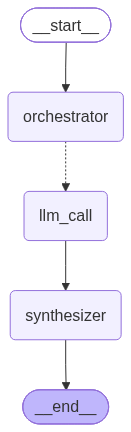

# Introduction: Why Scaling Laws Matter

The performance of large language models (LLMs) is not arbitrary. Across more than seven orders of magnitude in compute, researchers have repeatedly observed that test loss—the cross-entropy of a model on held-out text—declines as a smooth, predictable power law in three quantities: the number of model parameters $N$, the number of training tokens $D$, and the total compute budget $C$. This regularity is the central empirical fact motivating the study of scaling laws. It means that, within a broad regime, the loss of a model can be forecast *before* training begins, turning architecture and budget decisions from guesswork into quantitative optimization.

The modern literature on this topic begins with Kaplan et al. (2020), who trained a series of transformer language models spanning three orders of magnitude in size and found that loss follows $L(N, D) \propto N^{-\alpha} + D^{-\beta}$, with exponents $\alpha \approx 0.076$ and $\beta \approx 0.095$. Their analysis suggested that, for a fixed compute budget, it was more efficient to train very large models on relatively few tokens and to stop before convergence. This prescription shaped the design of models such as GPT-3.

Two years later, Hoffmann et al. (2022)—the Chinchilla paper—revised this picture. By training over 400 models under controlled conditions and fitting a more careful parametric form, they found that model size and training tokens should be scaled in roughly equal proportion: for every doubling of parameters, the number of training tokens should also double. Their 70B-parameter Chinchilla model, trained on 1.4 trillion tokens, outperformed the 280B-parameter Gopher on most benchmarks, demonstrating that earlier models were substantially *undertrained*. The Chinchilla correction has since become standard practice, and contemporary frontier models are routinely trained on trillions of tokens.

Several terms recur throughout this report and warrant precise definition. **Parameters ($N$)** refers to the number of trainable weights in the model, typically excluding embeddings and biases when fitting scaling laws. **Tokens ($D$)** denotes the number of training tokens processed, usually measured in a single epoch over a fixed corpus. **Compute ($C$)** is the total floating-point operations consumed during training, commonly approximated as $C \approx 6ND$ for a dense transformer. **Irreducible loss** is the asymptotic floor that loss approaches as $N$ and $D$ grow without bound—an entropy term reflecting the intrinsic unpredictability of natural language. Finally, a crucial distinction separates **training-optimal** scaling, which minimizes loss for a fixed training compute budget, from **inference-optimal** scaling, which accounts for the cost of serving the model after training. Because inference cost scales with $N$ while training cost scales with $ND$, the inference-optimal model is typically smaller and trained on more tokens than the training-optimal one—a tension that has become increasingly central as deployment costs dominate.

This report proceeds as follows. We first review the empirical foundations of scaling laws and the functional forms used to fit them. We then examine the Kaplan–Chinchilla debate and its implications for compute allocation. Subsequent sections address the limits of power-law extrapolation, the role of data quality and repetition, and the emerging practice of inference-aware scaling. We conclude with open questions, including whether scaling laws hold for downstream capabilities and how they interact with architectural innovations such as mixture-of-experts and retrieval.

---

# Foundational Scaling Laws (Kaplan et al., 2020)

## Overview

Kaplan et al. (2020), "Scaling Laws for Neural Language Models," established the first systematic empirical framework showing that transformer language model performance follows smooth, predictable power-law relationships with model size, dataset size, and compute. These laws enabled performance prediction prior to training and provided quantitative guidance for allocating compute budgets—most notably the finding that, for a fixed compute budget, allocating resources primarily to model size is more efficient than allocating them to data.

## Power-Law Relationships

The paper reports three core power-law relationships, each holding when the other two factors are not bottlenecks.

### 1. Performance vs. Model Size (N)

When trained on sufficiently large data (not data-limited), test loss follows a power law in the number of non-embedding parameters $N$:

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}, \quad \alpha_N \approx 0.076, \quad N_c \approx 8.8 \times 10^{13}$$

The exponent $\alpha_N \approx 0.076$ indicates that loss decreases slowly but steadily as model size grows—roughly a 5% reduction in loss for every 10× increase in parameters (in the non-saturated regime).

### 2. Performance vs. Dataset Size (D)

When trained with a sufficiently large model (not model-limited), test loss follows a power law in the number of training tokens $D$:

$$L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}, \quad \alpha_D \approx 0.095, \quad D_c \approx 5.4 \times 10^{13}$$

The exponent $\alpha_D \approx 0.095$ is slightly larger than $\alpha_N$, meaning data scaling yields marginally faster loss reduction per order of magnitude—but the two are comparable in magnitude.

### 3. Performance vs. Compute (C)

When both $N$ and $D$ are optimally allocated for a given compute budget $C$ (measured in PF-days), loss follows a power law in compute:

$$L(C_{\min}) = \left(\frac{C_c^{\min}}{C_{\min}}\right)^{\alpha_C^{\min}}, \quad \alpha_C^{\min} \approx 0.050, \quad C_c^{\min} \approx 3.1 \times 10^8$$

The exponent $\alpha_C^{\min} \approx 0.050$ is smaller than either $\alpha_N$ or $\alpha_D$ because compute must be split between model size and data, diluting the returns from either axis alone.

### Combined Functional Form

When all three factors are considered jointly, the loss is well-modeled by a sum of independent power-law terms plus an irreducible loss $L_\infty$:

$$L(N, D) = \left[\left(\frac{N_c}{N}\right)^{\alpha_N / \alpha_D} + \frac{D_c}{D}\right]^{\alpha_D}$$

or more generally:

$$L(N, D, C) \approx L_\infty + \left(\frac{N_c}{N}\right)^{\alpha_N} + \left(\frac{D_c}{D}\right)^{\alpha_D}$$

This additive form implies that the binding constraint is whichever term is largest—i.e., the model is either model-limited or data-limited, and performance is governed by the bottleneck.

## Model Size Matters More Than Data for Fixed Compute

A central and influential conclusion of Kaplan et al. is that, for a fixed compute budget $C$, optimal allocation strongly favors model size over data. Specifically, the optimal number of parameters $N_{\text{opt}}$ and optimal number of training tokens $D_{\text{opt}}$ scale as:

$$N_{\text{opt}} \propto C^{0.73}, \quad D_{\text{opt}} \propto C^{0.27}$$

This implies that as compute increases, model size should grow much faster than dataset size. The ratio $N_{\text{opt}} / D_{\text{opt}}$ increases with compute, meaning larger models should be trained on relatively fewer tokens (i.e., not to convergence on the data axis). The paper notes that $N$ and $D$ should be scaled such that $N \propto D^{0.73/0.27} \approx D^{2.7}$, or equivalently $D \propto N^{0.37}$.

This finding stood in contrast to later work (e.g., Hoffmann et al., 2022, "Chinchilla"), which revised the exponents to roughly $N_{\text{opt}} \propto C^{0.5}$ and $D_{\text{opt}} \propto C^{0.5}$, implying balanced scaling. The discrepancy is widely attributed to methodological differences (e.g., learning rate schedules, tokenization, and the treatment of embedding parameters).

## Architectural Hyperparameter Transfer

Kaplan et al. observed that optimal architectural hyperparameters—such as aspect ratio (depth/width), number of attention heads, and feed-forward ratio—are largely independent of model scale. That is, the same hyperparameters that work well for small models transfer to large models. This "hyperparameter transfer" property means that one can tune architecture on small models and apply the settings to large ones, dramatically reducing tuning cost. The paper reports that performance is relatively insensitive to these choices within a broad range, and that the scaling laws hold across architectures with different aspect ratios and head counts.

## Critical Batch Size

The paper introduces the concept of critical batch size $B_{\text{crit}}$, defined as the batch size at which the trade-off between compute efficiency and data efficiency is balanced. Below $B_{\text{crit}}$, increasing batch size reduces the number of optimization steps required without increasing the total data processed; above $B_{\text{crit}}$, further increases yield diminishing returns in step reduction and waste compute.

The critical batch size scales as a power law with the loss:

$$B_{\text{crit}}(L) = \frac{B_*}{L^{1/\alpha_B}}, \quad \alpha_B \approx 0.21, \quad B_* \approx 2 \times 10^8$$

Equivalently, $B_{\text{crit}} \propto L^{-1/\alpha_B} \approx L^{-4.8}$. This means that as training progresses and loss decreases, the critical batch size grows—larger batches become increasingly efficient later in training. The paper also relates $B_{\text{crit}}$ to model size and data, showing it scales with $N$ and $D$ in a predictable manner.

## Summary of Exponents

| Relationship | Exponent | Value | Constant |
|---|---|---|---|
| $L(N)$ | $\alpha_N$ | 0.076 | $N_c \approx 8.8 \times 10^{13}$ |
| $L(D)$ | $\alpha_D$ | 0.095 | $D_c \approx 5.4 \times 10^{13}$ |
| $L(C_{\min})$ | $\alpha_C^{\min}$ | 0.050 | $C_c^{\min} \approx 3.1 \times 10^8$ |
| $B_{\text{crit}}(L)$ | $\alpha_B$ | 0.21 | $B_* \approx 2 \times 10^8$ |
| $N_{\text{opt}}(C)$ | — | 0.73 | — |
| $D_{\text{opt}}(C)$ | — | 0.27 | — |

These exponents and functional forms provided the first quantitative blueprint for scaling language models and directly motivated the subsequent development of larger models such as GPT-3, while also setting the stage for the Chinchilla revision.

---

# The Chinchilla Correction

## Background: The Kaplan Scaling Laws and Their Influence

The modern era of scaling laws began with Kaplan et al. (2020), which proposed that model performance follows predictable power-law relationships with model size (N), dataset size (D), and compute (C). The paper's central practical claim was striking: given a fixed compute budget, one should allocate the vast majority of it to **increasing model size**, with relatively little data. Specifically, Kaplan et al. suggested that N should scale roughly as C^0.73 and D as C^0.27 — implying that as compute grows, models should balloon far faster than datasets. This conclusion shaped a generation of large language models: GPT-3 (175B parameters trained on ~300B tokens), Jurassic-1, Gopher (280B parameters on 300B tokens), and Megatron-Turing NLG (530B parameters) all reflected the "bigger model, same data" orthodoxy. The ratio of tokens to parameters in these models hovered around 1–2, far below what would later prove optimal.

## Hoffmann et al. (2022): The Chinchilla Correction

Hoffmann et al. (2022), working at DeepMind, revisited Kaplan's methodology and identified several confounds that had systematically biased the earlier results toward large models.

### Critique of Kaplan's Methodology

The Chinchilla authors identified three principal issues:

1. **Learning rate schedules.** Kaplan et al. used a fixed learning rate schedule across all training runs, with the schedule tuned primarily for the largest models. Smaller models were therefore trained suboptimally — they were effectively under-trained relative to their capacity, making them appear worse than they actually were. When Hoffmann et al. tuned the learning rate schedule per model size, the apparent advantage of large models shrank considerably.

2. **Cosine decay confounds.** Kaplan et al. used a cosine learning rate schedule whose period was set to the total number of training tokens. This meant that models trained on more tokens received a *different* effective learning rate trajectory, conflating the effect of dataset size with the effect of schedule length. The Chinchilla team showed that this confound distorted the estimated scaling exponents.

3. **Token-count and model-size entanglement.** Kaplan's fits did not cleanly separate the effects of N and D, and the use of a single training horizon across model sizes meant that the data-to-parameter ratio varied systematically with scale. This made it difficult to disentangle whether performance gains came from more parameters or from more data.

### The Revised Finding: Proportional Scaling

After correcting for these issues, Hoffmann et al. arrived at a fundamentally different conclusion. The compute-optimal allocation is approximately:

- **N_opt ∝ C^0.5**
- **D_opt ∝ C^0.5**

In other words, model size and dataset size should scale **roughly proportionally** with compute. The practical rule of thumb that emerged: **approximately 20 tokens per parameter**. A 70B-parameter model should therefore be trained on ~1.4T tokens, not the ~140B tokens that Kaplan-style scaling would have suggested.

The Chinchilla paper's headline result was that Chinchilla (70B parameters, 1.4T tokens) outperformed Gopher (280B parameters, 300B tokens), despite using roughly the same compute budget — a 4× smaller model trained on ~4.7× more data.

### Three Estimation Approaches

Hoffmann et al. used three complementary methods to derive their scaling laws, which lent the result robustness:

1. **Fixed model sizes.** They trained models of several fixed sizes (70M to 16B parameters) on varying numbers of tokens, then fit a parametric loss function L(N, D) to the resulting loss surface. This approach directly estimates the joint dependence on N and D.

2. **IsoFLOP profiles.** For a range of fixed compute budgets (from 6×10^18 to 3×10^21 FLOPs), they trained models of varying sizes and recorded the final loss. Each IsoFLOP curve has a minimum, and the locus of these minima traces the compute-optimal frontier. This method is model-agnostic and does not assume a particular functional form.

3. **Parametric fit.** They fit a functional form L(N, D) = E + A/N^α + B/D^β to all data points, then minimized loss subject to the constraint C ≈ 6ND. This yielded the closed-form exponents and the ~20 tokens/parameter rule.

The convergence of all three methods on the same qualitative conclusion — proportional scaling — was a key reason the result was quickly accepted.

### The Compute-Optimal Frontier

The resulting frontier specifies, for any compute budget C, the optimal (N, D) pair. The frontier is approximately linear in log-log space, with N and D both scaling as C^0.5. This means that as compute grows, one should scale model size and dataset size in tandem, rather than favoring one over the other. The frontier also implies that **most models at the time were significantly undertrained** — they had too many parameters for the amount of data they had seen.

## Practical Consequences

### LLaMA and the Data-Forward Shift

The most direct practical consequence was LLaMA (Touvron et al., 2023), which explicitly adopted the Chinchilla recipe. LLaMA-7B was trained on 1T tokens (~140 tokens/parameter), LLaMA-13B on 1T tokens, and LLaMA-65B on 1.4T tokens (~21 tokens/parameter). The results validated the Chinchilla thesis: LLaMA-13B outperformed GPT-3 (175B) on most benchmarks, and LLaMA-65B was competitive with Chinchilla-70B and PaLM-540B. The LLaMA family demonstrated that **smaller models trained on more data** could match or exceed much larger models trained on less data, at a fraction of the inference cost.

### The Broader Shift

The Chinchilla correction catalyzed a broad reorientation of the field:

- **Data became the bottleneck.** Labs began aggressively collecting and curating training data, and "data quality" and "data mixing" became first-class research topics. The focus shifted from "how big can we make the model?" to "how much high-quality data can we get?"
- **Inference economics.** Smaller, better-trained models are cheaper to serve. The Chinchilla result made it clear that over-parameterized models were not just suboptimal for training — they were expensive to deploy.
- **Subsequent scaling laws.** Later work (e.g., Llama 2, Llama 3, and the "over-training" literature) showed that for inference-optimal models, one should train *beyond* the Chinchilla point — sometimes 100–1000 tokens per parameter — because inference cost dominates training cost over a model's lifetime. Llama 3 8B, for instance, was trained on 15T tokens (~1,875 tokens/parameter).
- **Re-evaluation of prior models.** GPT-3, Gopher, and similar models were retrospectively understood to be undertrained, and their capabilities were reinterpreted as evidence of the importance of data rather than raw parameter count.

In summary, the Chinchilla correction replaced the "bigger is better" heuristic with a more nuanced, compute-aware prescription: **scale model and data together, and expect ~20 tokens per parameter as the training-optimal baseline** — a baseline that subsequent work has pushed even further in the data-forward direction.

---

# Beyond Chinchilla: Inference-Aware and Over-Training Regimes

## The Inference Cost Blind Spot in Chinchilla

The Chinchilla scaling laws (Hoffmann et al., 2022) established that, for a fixed *training* compute budget, model loss is minimized by scaling parameters $N$ and training tokens $D$ in roughly equal proportion, yielding the celebrated $D \approx 20N$ rule. This result is correct but incomplete: it optimizes only the one-time cost of training, ignoring the recurring cost of inference. For any model that will serve more than a handful of queries, inference dominates lifetime compute. Kaplan et al. (2020) had already noted that the compute-optimal frontier depends on the objective, but the field largely internalized the $20N$ heuristic as a universal target—until deployed models like LLaMA-2, LLaMA-3, and Mistral visibly violated it, training far smaller models on far more tokens than Chinchilla prescribes.

## The Total-Cost Objective

The inference-aware framing treats the relevant quantity as the **total lifetime cost** of a model:

$$
C_{\text{total}} = \underbrace{6ND}_{\text{training FLOPs}} + \underbrace{2N \cdot Q}_{\text{inference FLOPs}}
$$

where $Q$ is the total number of tokens the model will process over its deployment lifetime (prompt + generated tokens, summed across all requests), and the factors 6 and 2 are the standard forward/backward and forward-only FLOP multipliers. The first term is paid once; the second scales with deployment volume. Minimizing loss subject to a *fixed total budget* $C_{\text{total}}$—rather than a fixed training budget—changes the optimum qualitatively.

Solving the constrained optimization with a Chinchilla-style power-law loss $L(N, D) = E + A N^{-\alpha} + B D^{-\beta}$ yields an optimal token-to-parameter ratio that grows with the inference-to-training cost ratio. As $Q \to 0$ (a model trained and barely used), the classic $D \approx 20N$ result is recovered. As $Q$ grows large—the realistic case for any widely deployed model—the optimum shifts toward **smaller $N$ and much larger $D$**. The model is deliberately "over-trained" relative to Chinchilla because parameters are the expensive thing at inference time, while tokens are cheap at training time.

## Over-Training as Rational Behavior

"Over-training" is a misnomer: it is only over-training relative to a budget that ignores inference. Under the total-cost objective it is the *correct* choice. The intuition is straightforward:

- **Parameters are a recurring tax.** Every forward pass costs $\propto N$. A model with half the parameters costs half as much per token served, forever.
- **Tokens are a one-time investment.** Extra training tokens cost compute once, then amortize across the entire deployment.
- **Deployment volume is the deciding variable.** The larger $Q$, the more aggressively it pays to shrink $N$ and extend $D$.

This is precisely the regime LLaMA-2 and LLaMA-3 occupy. LLaMA-2 7B was trained on 2T tokens ($\approx 285$ tokens/param); LLaMA-3 8B on 15T tokens ($\approx 1{,}875$ tokens/param)—roughly 90× beyond Chinchilla-optimal. Mistral 7B and its successors follow the same pattern. These are not scaling-law violations; they are scaling-law *applications* under a different objective.

## The Optimal Ratio Depends on the Cost Ratio

The central practical result is that the optimal $D/N$ is not a constant but a function of the ratio of inference to training cost. Define $r = Q / D_{\text{train}}$ (roughly, how many times the model is "reused" over its life). Then the optimal ratio scales approximately as:

$$
\frac{D^*}{N^*} \propto r^{\,\frac{\alpha}{\alpha + \beta}}
$$

with the exponent typically in the range of 0.3–0.5 for empirical loss exponents. This has several consequences:

1. **No universal token/parameter target exists.** The "right" ratio is deployment-specific. A model served a million times should be trained far longer per parameter than one served a thousand times.
2. **Small models win at high volume.** For high-$Q$ deployments, the total-cost-optimal model is smaller and longer-trained than the training-optimal one—sometimes dramatically so.
3. **The frontier is a surface, not a curve.** Each deployment volume $Q$ defines its own optimal $(N, D)$ locus, and the Chinchilla curve is just the $Q \to 0$ edge of that surface.

## Implications

The inference-aware view reframes several open questions. It explains the empirical convergence of frontier labs on small, heavily-trained models for serving, while reserving larger models for low-volume or latency-critical use. It implies that **data quality and quantity become more valuable than parameter count** as deployment volume rises, since the binding constraint shifts to tokens. It also suggests that distillation, quantization, and other inference-cost-reduction techniques interact with the training/inference trade-off—each reduces the effective $N$ or $Q$ and thus moves the optimum. Finally, it cautions against evaluating scaling decisions in isolation from the deployment context: a model that looks "wastefully over-trained" under Chinchilla may be exactly optimal once its serving economics are accounted for.

---

# Emergent Abilities and Their Disputed Nature

## The Emergence Claim

Wei et al. (2022) documented a striking pattern across large language models: certain capabilities appear to materialize abruptly once models cross a threshold of scale, rather than improving gradually with additional parameters or training compute. Tasks such as multi-step arithmetic, symbolic reasoning, and certain forms of in-context learning were reported to show near-zero performance in smaller models followed by sharp, discontinuous jumps to substantial accuracy in larger ones. This framing proved influential because it suggested that scaling does not merely refine existing abilities but unlocks qualitatively new ones—capabilities that are, in a meaningful sense, absent in smaller models and present in larger ones. The narrative aligned with a broader intuition that sufficiently large models cross thresholds into competence regimes that cannot be extrapolated from the behavior of their smaller predecessors.

## The Artifact Counterargument

Schaeffer et al. (2023) challenged this account directly, arguing that apparent emergence is frequently an artifact of the metrics chosen to evaluate performance rather than a property of the models themselves. Their central observation is that many "emergent" tasks are scored with discontinuous, all-or-nothing metrics—exact-match accuracy on a final answer, for instance—which remain near zero until a model's underlying competence is sufficient to clear the threshold for a fully correct response. When the same models are evaluated with smoother, more granular metrics (such as token-level accuracy, partial credit, or the probability assigned to correct answers), performance improves gradually and predictably with scale. Under this view, the discontinuity lives in the measurement instrument, not in the model. The sharp jump is a consequence of thresholding a continuous underlying signal.

## Reconciling Loss Curves and Downstream Performance

This dispute reframes a long-standing puzzle: why do smooth, monotonic improvements in pretraining loss coexist with seemingly discontinuous jumps in downstream task performance? The reconciliation offered by the artifact critique is that the two are not in tension. Pretraining loss is a smooth aggregate measure of predictive competence, and it continues to improve gradually. Downstream metrics that impose hard thresholds on that competence will convert a smooth underlying trajectory into a step function. The model's capabilities may therefore be improving continuously even when the reported task accuracy appears to jump. Conversely, the emergence proponents would note that for practical purposes, a capability that only manifests as usable output above a certain scale is genuinely absent below it—smooth latent competence that never crosses the threshold for correct answers has limited utility.

## The Role of Metric Choice

The debate ultimately elevates metric selection from a methodological afterthought to a central interpretive decision. Whether one observes emergence depends substantially on whether the evaluation metric is continuous or discrete, and on where thresholds are placed. This has several implications. First, claims of emergence should be accompanied by explicit justification of the metric and, ideally, by reporting performance under alternative metrics to test robustness. Second, comparisons across models of different scales are only meaningful when the metric behaves consistently across the range of competence being measured. Third, the choice of metric encodes a normative judgment about what counts as having a capability—a judgment that is often left implicit.

## Implications for Interpretation

The dispute does not resolve cleanly in favor of either side. It is likely that some capabilities are genuinely discontinuous in their functional manifestation while others are artifacts of coarse measurement, and distinguishing the two requires careful, metric-aware analysis. The practical lesson is that smooth loss curves and discontinuous task performance are not contradictory observations requiring a single explanation; they are different views of the same underlying system, filtered through different measurement choices. Interpreting scaling behavior responsibly therefore requires attending to both the model's latent competence and the instrument used to probe it—and treating the boundary between "emergent" and "gradual" as partly a question of how we choose to measure.

---

# Data Scaling, Quality, and the Data Wall

## Repeated Epochs and Diminishing Returns

The classical scaling-law paradigm assumes access to a virtually unlimited stream of unique tokens, but in practice most training corpora are finite and must be traversed multiple times. Muennighoff et al. (2023) systematically characterized the effect of repeated training on the same data, extending the Chinchilla-style compute-optimal framework to the regime where unique tokens are the binding constraint. Their central finding is that repeating data yields diminishing returns: up to roughly four epochs, additional passes are nearly as valuable as fresh tokens, but beyond this point the marginal value of each additional epoch decays sharply, eventually approaching zero. They formalize this by introducing an *effective number of tokens* that discounts repeated tokens relative to unique ones, allowing the standard scaling laws to be recovered with a modified token count. This result has an important corollary: when unique data is scarce, the compute-optimal strategy shifts toward *smaller* models trained for *more* epochs, rather than larger models trained on the same limited data. The upshot is that repetition provides a partial but bounded substitute for data abundance—it buys time against the data wall but does not remove it.

## Data Quality Filtering and Deduplication

Raw web crawls are far from an ideal training distribution, and the gap between "all crawled text" and "high-quality text" is where much of the recent progress in data efficiency has come from. Deduplication—both exact and fuzzy, at the document and substring level—has been shown to reduce memorization, improve training stability, and yield better downstream performance for a given token budget (Lee et al., 2022). Quality filtering, typically implemented via heuristic rules (length, perplexity, presence of boilerplate) or learned classifiers that score text against a high-quality reference distribution, produces further gains. The effects are large enough to matter at the frontier: models trained on aggressively filtered and deduplicated subsets can match or exceed models trained on much larger unfiltered corpora. This has an important implication for the data wall: the *effective* size of the high-quality data pool is not fixed by the raw crawl volume but is a function of filtering sophistication. Better filters expand the usable pool, but they also raise the bar for what counts as "high quality," and the returns to ever-more-aggressive filtering are themselves subject to diminishing returns and risk of distributional narrowing.

## Mixture and Domain Weighting Laws

Beyond filtering individual documents, the *composition* of the training mixture across domains (code, natural language, mathematics, multilingual text) has emerged as a first-class scaling variable. Empirical work has established that domain weights follow their own scaling behavior: performance on a target domain is a predictable function of the fraction of training tokens allocated to it, and the optimal mixture depends on the evaluation distribution and the total token budget. This has motivated both heuristic reweighting schemes and more principled approaches that treat mixture weights as hyperparameters to be optimized under a compute budget. The practical consequence is that data scaling is not merely a question of *how much* data but of *what kind*—and that the effective supply of high-quality data is domain-specific. Code and mathematical text, in particular, are far scarcer than general web text, so the data wall arrives earlier for these domains than for natural language at large.

## The Prospect of Exhausting High-Quality Web Text

Projections based on the growth rate of high-quality web text and the token budgets of frontier models suggest that the stock of readily available, high-quality human-generated text could be substantially consumed within the current decade (Villalobos et al., 2022). These estimates are sensitive to assumptions about filtering thresholds, multilingual inclusion, and the fraction of the web that is genuinely useful for training, but the qualitative conclusion is robust: the era of effectively unlimited high-quality text is finite. This prospect is the concrete form of the "data wall." It does not imply that scaling stops, but it does imply that the historical pattern—more compute plus more data yielding predictable gains—cannot continue indefinitely without new sources of training signal.

## Synthetic Data, Multimodal Data, and the Frontier

Two broad responses to the data wall are already visible. The first is synthetic data: generating training examples from existing models, either through self-play, distillation, or curated generation pipelines. Synthetic data can be scaled arbitrarily and can be targeted at specific capabilities, but it carries well-documented risks of model collapse, distributional narrowing, and amplification of existing biases when used naively. Careful mixing of synthetic and real data, verification against ground truth, and iterative filtering can mitigate these risks, and in some domains (notably code and mathematics, where correctness is checkable) synthetic data has proven highly effective. The second response is multimodal data: images, audio, video, and other modalities offer orders of magnitude more raw signal than text alone, and while the *useful* fraction is again much smaller than the raw volume, the ceiling is far higher. Whether these sources can substitute for the diminishing returns of text is an open empirical question, but they clearly change the shape of the scaling curve rather than merely shifting it.

The deeper question is whether data-constrained scaling changes the frontier. If unique high-quality tokens are the binding constraint, then compute-optimal training shifts toward smaller models, more epochs, and better data curation—a regime in which algorithmic and data-efficiency gains matter more than raw scale. This does not eliminate scaling laws, but it changes which axis of scaling is most productive. The frontier may continue to advance, but through a different mix of levers than the one that defined the previous generation of models.

---

# Architecture, Hyperparameters, and Transfer

## Aspect Ratio and Depth/Width Tradeoffs

Scaling laws are typically fit as functions of a single parameter count $N$, but $N$ is not a sufficient statistic for architecture. Two models with identical parameter counts can differ substantially in loss depending on how those parameters are distributed across depth, width, and the aspect ratio $d_{\text{model}}/n_{\text{layer}}$.

Empirically, for a fixed compute budget, loss is relatively flat across a broad range of aspect ratios, with a shallow optimum. Kaplan et al. (2020) found that performance depends only weakly on shape for fixed $N$, while subsequent work (e.g., Levine et al., 2020; the "shape-optimized" analyses in the Chinchilla line) showed that aspect ratio interacts with learning rate and that the optimal aspect ratio drifts with scale. The practical implication is that depth/width tradeoffs are second-order relative to $N$ and $D$ in the compute-optimal regime, but not negligible: at very large $N$, deeper models tend to be more sample-efficient per parameter, while wider models are more parallelizable and less prone to optimization instability.

A useful framing is that architecture choices typically shift the *constant* in a scaling law rather than the *exponent*. If loss follows $L(N) = L_\infty + (N_c/N)^{\alpha}$, changing aspect ratio or depth/width mostly moves $N_c$ (the "effective" parameter scale) and $L_\infty$, leaving $\alpha$ roughly invariant. This is why architecture search at small scale often transfers: the ranking is preserved even when absolute losses differ.

## Mixture-of-Experts Scaling Laws

Sparse mixture-of-experts (MoE) models decouple total parameters $N$ from active parameters per token $N_{\text{act}}$. This breaks the standard $L(N)$ law into at least two axes, and the relevant scaling variables become $(N_{\text{act}}, N_{\text{total}}, D)$.

Key empirical findings:

- **Active parameters dominate loss.** For fixed $D$, loss is governed primarily by $N_{\text{act}}$, with $N_{\text{total}}$ providing a smaller, saturating benefit. This is the "sparse scaling law" result from Clark et al. (2022) and refined in subsequent work.
- **Expert count and granularity matter.** Increasing the number of experts at fixed $N_{\text{act}}$ (i.e., finer granularity) improves loss up to a point, then plateaus or degrades due to routing overhead and load-balancing pressure.
- **Compute-optimal MoE is not compute-optimal dense.** Because MoE trades memory and communication for FLOPs, the compute-optimal frontier shifts: for a given FLOP budget, MoE can reach lower loss than dense, but the optimal $D/N_{\text{act}}$ ratio differs.

The scaling law form is often written as $L = L_\infty + a N_{\text{act}}^{-\alpha} + b N_{\text{total}}^{-\beta} + c D^{-\gamma}$, with $\alpha > \beta$ typically, reflecting the stronger dependence on active parameters. Architecture choices (top-k routing, expert size, shared experts) primarily modulate $a$, $b$, and the saturation behavior rather than the exponents.

## Learning Rate and Batch Size Scaling

Learning rate and batch size are not free hyperparameters; they have their own scaling laws that interact with model size and data size.

- **Critical batch size.** There exists a critical batch size $B_{\text{crit}}$ below which training is compute-inefficient (too many steps for the loss reduction achieved) and above which returns diminish. $B_{\text{crit}}$ grows with model size and with the noise scale of the gradient, roughly as $B_{\text{crit}} \propto 1/(L - L_\infty)$ near the noise floor (McCandlish et al., 2018).
- **Learning rate scaling.** Optimal learning rate typically decreases with model width (for standard parameterization) and increases with batch size following a power law $\eta^* \propto B^{p}$ with $p \approx 0.5$ in the linear regime, flattening at large $B$.
- **Warmup and schedule.** The optimal warmup length and decay schedule also scale with $N$ and $D$, though these are usually treated as constants in scaling-law fits.

These relationships mean that a scaling law fit at one (learning rate, batch size) configuration can be misleading if those hyperparameters are not themselves scaled. The "compute-optimal" frontier is only well-defined once the inner optimization over $\eta$ and $B$ is accounted for.

## muP and µTransfer

Standard parameterization (SP) requires re-tuning the learning rate and initialization as width grows, because the optimal $\eta$ drifts with $d_{\text{model}}$. This makes hyperparameter transfer across scales expensive: a learning rate tuned at 100M parameters is wrong at 10B.

Maximal Update Parameterization (µP) (Yang & Hu, 2021) fixes this by scaling initialization, learning rates, and attention logits with width so that the optimal hyperparameters are approximately invariant to width. The resulting technique, **µTransfer**, allows hyperparameters (learning rate, init scale, warmup, even some architecture choices) to be tuned on a small proxy model and transferred zero-shot to a much larger target.

Practical implications:

- µTransfer has been demonstrated to transfer learning rates, initialization, and even some optimizer settings from ~40M to ~6.7B parameter models with minimal loss penalty.
- It does not eliminate the need for scaling laws; it makes the *hyperparameter* axis of the scaling law approximately scale-invariant, so that the remaining scaling is in $N$ and $D$.
- µP is architecture-sensitive: it must be derived for each layer type (attention, MLP, embeddings, normalization), and deviations (e.g., non-standard residual scaling) can break transfer.

## Does Architecture Shift the Frontier or the Constant?

The recurring empirical pattern is that most architecture changes shift the *constant* of the scaling law, not the exponent. Concretely:

- **Shifts the constant (most common):** aspect ratio, depth/width tradeoff, activation function, normalization placement, attention variant (within reason), MoE granularity at fixed $N_{\text{act}}$. These change $L_\infty$ or $N_c$ but leave $\alpha$ roughly intact.
- **Shifts the frontier (rarer):** changes that alter the *effective* compute or data efficiency in a way that cannot be absorbed into a constant. Examples include:
  - MoE, which changes the relevant $N$ from total to active parameters and thus redefines the axis.
  - Retrieval or external memory, which changes the effective $D$ by making some tokens cheaper to predict.
  - Architectural changes that improve optimization stability enough to allow larger $\eta$ or $B$, effectively moving the compute-optimal point.

The practical takeaway: when evaluating a new architecture, the first question is whether it changes the exponent (frontier) or the constant (offset). Most changes are constants, which means they are worth a fixed factor of compute but do not change the long-run scaling behavior. The exceptions—MoE, retrieval, and optimization-stability improvements—are the ones that genuinely move the frontier and are therefore the most consequential at scale.

---

# Limitations, Critiques, and Open Questions

## Methodological Critiques

### Extrapolation Risk

Scaling laws are, at their core, empirical fits to a bounded region of the compute–data–parameter space. Fitting a power law over models spanning several orders of magnitude and then extrapolating to frontier scales assumes that the functional form remains stable beyond the observed regime. This assumption is fragile: the exponents themselves are estimated with uncertainty that compounds under extrapolation, and there is no guarantee that a single power law governs all regimes. Transitions—such as a shift from data-limited to compute-limited scaling, or the onset of diminishing returns from irreducible loss—can invalidate extrapolations that appeared well-calibrated in-sample. The practical consequence is that predicted frontier performance may be systematically optimistic or pessimistic, and the confidence intervals around such predictions are often understated.

### Dependence on Tokenizer and Data Distribution

Loss is measured in units defined by the tokenizer, which makes cross-model comparisons treacherous. A model trained on a more aggressive subword vocabulary may report lower per-token loss while achieving equivalent or worse per-character or per-task performance. Similarly, scaling coefficients are conditioned on the pretraining distribution: a law fit on web text need not transfer to code, mathematical corpora, or multilingual data, each of which exhibits different entropy and redundancy structure. Because data mixtures are rarely held constant across scales—often shifting toward higher-quality sources as compute grows—the effective distribution changes with scale, confounding the very variable being predicted.

### Loss as a Proxy for Capability

Pretraining loss is a coarse summary statistic that aggregates performance across all tokens, weighting frequent and trivial predictions alongside rare and informative ones. Two models with identical loss can differ substantially in reasoning, factual recall, or instruction-following ability. Loss is also insensitive to the qualitative discontinuities that matter most for deployment—emergent capabilities, sharp transitions in in-context learning, and the onset of specific skills. Treating loss as a sufficient statistic for capability conflates a smooth optimization objective with a highly non-smooth, task-dependent performance landscape.

### Benchmark Contamination

As pretraining corpora grow to trillions of tokens, the probability that evaluation sets leak into training data approaches certainty for many popular benchmarks. Contamination inflates reported performance in ways that are difficult to detect and rarely corrected, and it interacts perversely with scaling: larger models, trained on more data, are more likely to have memorized benchmark items, so apparent scaling gains may partly reflect memorization rather than generalization. Contamination also undermines the use of benchmarks as held-out proxies for downstream utility, since the very act of scaling increases exposure.

### The Gap Between Pretraining Loss and Downstream Utility

Even a perfectly estimated loss curve says little about whether a model will be useful for a given task after fine-tuning, prompting, or RLHF. Downstream utility depends on factors orthogonal to pretraining loss: instruction-following fidelity, calibration, refusal behavior, tool use, and robustness to distribution shift. The mapping from loss to utility is task-specific and often non-monotonic—improvements in loss can coincide with regressions in safety or factuality. This gap means that scaling laws for loss cannot be directly translated into scaling laws for the capabilities that practitioners actually care about.

## Open Questions

### Scaling Laws for RLHF and Post-Training

Pretraining scaling laws are comparatively well understood; the scaling behavior of post-training—supervised fine-tuning, reward modeling, and RLHF—is not. It remains unclear whether post-training exhibits its own power laws, whether those laws depend on the pretraining checkpoint in a predictable way, and how compute should be allocated between pretraining and post-training to maximize downstream performance. Reward model scaling, the sample efficiency of preference data, and the interaction between KL constraints and policy improvement all lack established functional forms.

### Reasoning and Test-Time Compute Scaling

A growing body of work suggests that allocating additional compute at inference—through chain-of-thought, sampling, search, or verification—can improve reasoning performance in ways that are not captured by pretraining loss. Whether test-time compute follows its own scaling law, how it interacts with model scale, and where its returns diminish are open empirical questions. The possibility that test-time scaling can substitute for parameter scaling, or that the two are complementary in a predictable ratio, has significant implications for how frontier systems are built and deployed.

### Do Power Laws Hold at Frontier Scales?

The most consequential open question is whether the power laws observed at small and medium scales continue to hold at the frontier. Several mechanisms could cause deviation: irreducible loss floors, data exhaustion, architectural bottlenecks, or the emergence of qualitatively new failure modes. Conversely, improvements in data quality, architecture, and training procedures could shift the curves upward, effectively resetting the frontier. Resolving this question requires either continued empirical observation at increasing scale or theoretical grounding that explains why a particular functional form should persist—neither of which is currently available. Until then, frontier predictions should be treated as informed extrapolations rather than reliable forecasts.

---

# Practical Implications and Conclusion

## From Scaling Laws to Compute Allocation

Scaling laws convert an empirical regularity into an operational tool: they predict loss as a function of compute, data, and parameters, which means they can be inverted to answer the question practitioners actually care about—*given a fixed budget, how should I spend it?* The central practical takeaway is that compute allocation is an optimization problem with a known functional form. For a fixed compute budget $C \approx 6ND$ (FLOPs for training a model with $N$ parameters on $D$ tokens), the Chinchilla-style prescription is to scale parameters and data roughly in proportion, $N \propto C^{0.5}$, $D \propto C^{0.5}$. The older Kaplan-style prescription ($N \propto C^{0.73}$) systematically over-allocated to parameters and under-allocated to data, and models trained under it were compute-inefficient by a large factor. The practical lesson is not "Chinchilla's exponents are correct" but "the exponents matter enormously, and they should be re-estimated for your setting rather than assumed."

Three allocation decisions follow directly:

1. **Training vs. data acquisition.** If data is the binding constraint, the marginal value of additional unique tokens can exceed the marginal value of additional parameters. Deduplication, filtering, and synthetic data generation become compute-allocation decisions, not just data-engineering hygiene.
2. **Model size vs. training duration.** For a fixed inference budget, it is often optimal to train a *smaller* model for *longer* (over-training relative to the compute-optimal point) because inference cost scales with $N$ while training cost is amortized. This is the "inference-aware" scaling regime, and it inverts the naive compute-optimal recommendation.
3. **Pretraining vs. post-training vs. test-time compute.** Once test-time compute is in the picture, the budget is no longer a single training run. The relevant question becomes how to split a total compute envelope across pretraining, fine-tuning/RLHF, and inference-time search or reasoning.

## Budget Planning Under Uncertainty

Scaling laws are most useful for *relative* planning and least reliable for *absolute* forecasting. A defensible planning workflow:

- **Fit locally, extrapolate cautiously.** Estimate exponents from runs spanning at least 2–3 orders of magnitude in compute. Extrapolating more than ~1 order of magnitude beyond the fitted range is where predictions degrade, and the degradation is usually in the optimistic direction (real loss is higher than predicted).
- **Budget for the irreducible loss term.** The scaling law $L(C) = L_\infty + (C_c/C)^\alpha$ has a floor $L_\infty$ that cannot be removed by more compute. If your target loss is below the estimated floor, no budget will reach it; the correct response is a change in data, architecture, or objective, not more GPUs.
- **Treat exponents as uncertain.** Report confidence intervals on $\alpha$ and $L_\infty$. A 10% error in $\alpha$ compounds into a large error in the predicted compute needed to hit a target, and this uncertainty should propagate into timelines and cost estimates.
- **Separate capability from loss.** Loss is a smooth, predictable proxy; downstream benchmark performance is often a step function or a power law with different exponents. Budget for the *capability* you need, using loss only as an intermediate signal.

## Designing Scaling Experiments

A scaling experiment is only as good as its design. Practical guidance:

- **Vary one axis at a time, but fit jointly.** To recover $N$ and $D$ exponents, you need a grid, not a line. IsoFLOP profiles—training many (N, D) pairs at fixed compute—are the gold standard because they directly reveal the compute-optimal frontier rather than assuming it.
- **Control for data quality and tokenizer.** Exponents fitted on one data distribution do not transfer to another. Re-fit when the data pipeline changes materially.
- **Use learning-rate transfer.** Optimal learning rate scales predictably with model size and batch size; fixing it incorrectly biases the fitted exponents. Either tune per run or use a validated transfer rule.
- **Watch for contamination and saturation.** As models approach the data ceiling, the data exponent changes. A scaling law fitted before saturation will over-predict the value of more data.
- **Report the fit, not just the frontier.** Publish the raw runs, the functional form, and the residuals. The residuals are where the interesting regime changes hide.

## When to Trust Extrapolations

Trust extrapolations when: the functional form is motivated (not just curve-fit), the fit spans several orders of magnitude, residuals are structureless, and the mechanism is understood (e.g., more data reduces variance in the same way across scales). Distrust them when: you are extrapolating past a known regime boundary (data saturation, architecture change, emergence of new capabilities), when the target metric is discontinuous, or when the fit is dominated by a single large run. A useful heuristic: extrapolate for *ranking* decisions (which of two configurations is better) more readily than for *absolute* predictions (how much compute to reach a specific loss).

## Outlook: Test-Time Compute and Multimodal Regimes

The scaling-law framework is being extended in two directions that change the practical calculus:

**Test-time compute.** Inference-time scaling—longer chains of thought, search, sampling, and verification—trades compute at deployment for capability. Early evidence suggests test-time scaling follows its own power law, and that it can substitute for model scale on reasoning-heavy tasks. The practical implication is that the optimal allocation is no longer a single training run but a *portfolio*: a smaller base model plus a larger inference budget can dominate a larger base model on tasks where verification is cheap. This shifts the economics toward inference infrastructure and toward training models that are *good at being scaled at test time* (e.g., via RL on reasoning traces).

**Multimodal models.** Adding modalities changes both the data exponent and the loss floor. Vision, audio, and video tokens have different information densities and different scaling behavior; a single "tokens" axis is no longer sufficient. The practical guidance is to fit modality-specific exponents and to expect the compute-optimal allocation across modalities to differ from the text-only prescription. Multimodal scaling also introduces new evaluation challenges, since loss on one modality may not track capability on another.

## Conclusion

Scaling laws are best understood as a *decision framework*, not a crystal ball. They tell you how to allocate a fixed compute budget, where the marginal returns are, and when more compute will not help. Their practical value comes from being fitted locally, validated against held-out scales, and used for relative rather than absolute predictions. The frontier is moving from "how big a model can we train" to "how do we allocate a portfolio of pretraining, post-training, and test-time compute across multiple modalities"—and the same empirical discipline that made scaling laws useful for the first question is what will make them useful for the next.

In [13]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
show_graph(orchestrator_worker)

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

Markdown(state["final_report"])

## Evaluator-optimizer

在 evaluator-optimizer workflow 中, 一次 LLM 调用生成响应, 另一次 LLM 调用评估该响应。如果评估方或 [human-in-the-loop](https://docs.langchain.com/oss/langgraph/interrupts) 判断响应需要改进, 就会给出反馈并重新生成响应。这个循环会一直持续到生成可接受的响应为止。

当任务有明确的成功标准、但需要反复迭代才能达标时, 通常会使用 evaluator-optimizer workflow。例如, 在两种语言之间翻译文本时, 并不总能一次到位; 可能需要几次迭代, 才能得到在两种语言中含义一致的译文。

![evaluator_optimizer.png](https://docs.langchain.com/oss/images/evaluator_optimizer.png)

### Graph API

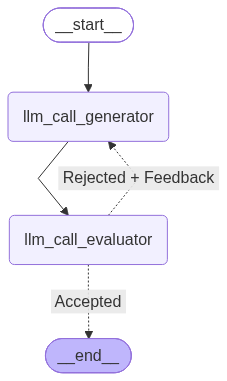

Why did the cat join a band?

Because he wanted to be the **purr**cussionist!

In [14]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
show_graph(optimizer_workflow)

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
rprint(state["joke"])

### Functional API

`Feedback` schema 与 `evaluator` 已在上文 Graph API 中定义, 此处直接复用。

In [15]:
# Nodes
@task
def llm_call_generator(topic: str, feedback: Feedback):
    """LLM generates a joke"""
    if feedback:
        msg = llm.invoke(
            f"Write a joke about {topic} but take into account the feedback: {feedback}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def llm_call_evaluator(joke: str):
    """LLM evaluates the joke"""
    feedback = evaluator.invoke(f"Grade the joke {joke}")
    return feedback


@entrypoint()
def optimizer_workflow(topic: str):
    feedback = None
    while True:
        joke = llm_call_generator(topic, feedback).result()
        feedback = llm_call_evaluator(joke).result()
        if feedback.grade == "funny":
            break

    return joke

# Invoke
stream = optimizer_workflow.stream_events("Cats", version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

[
    {
        'type': 'text',
        'text': 'Why did the cat join a band?\n\nBecause he wanted to be the **purr**cussionist!',
        'index': 0
    }
]

## Agents

Agent 通常被实现为 LLM 使用 [tools](https://docs.langchain.com/oss/langchain/tools) 执行操作。它们在持续的反馈循环中运行, 适用于问题与解法都不确定的场景。Agent 比 workflow 拥有更多自主性, 可以自行决定使用哪些 tools 以及如何解决问题。你仍然可以定义可用的 toolset, 以及 agent 行为方式的准则。

![agent.png](https://docs.langchain.com/oss/images/agent.png)

> **注意**
>
> 要开始使用 agents, 请参阅 [快速入门](https://docs.langchain.com/oss/langchain/quickstart), 或进一步了解它们在 LangChain 中的 [工作原理](https://docs.langchain.com/oss/langchain/agents)。

### Using tools

In [16]:
# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

### Graph API

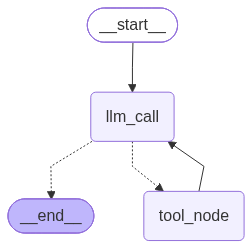

HumanMessage(
    content='Add 3 and 4.',
    additional_kwargs={},
    response_metadata={},
    id='92f11ee5-9353-45b9-a3eb-6a378bc03232'
)

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 52,
            'prompt_tokens': 471,
            'total_tokens': 523,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 256},
            'prompt_cache_hit_tokens': 256,
            'prompt_cache_miss_tokens': 215
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-flash',
        'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
        'id': '59741a1b-6f72-4699-b8ed-4e609f9760dc',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--01a0fad0-2ffd-76c3-ae60-ef6afe8b9826-0',
    tool_calls=[
        {'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_00_EPpLLXBIEzWiqJjtmQH18181', 'type': 'tool_call'}
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 471,
        'output_tokens': 52,
        'total_tokens': 523,
        'input_token_details': {'cache_read': 256},
        'output_token_details': {}
    }
)

ToolMessage(
    content='7',
    id='c9be8e0a-fb40-4dda-9cb9-36de851d58c1',
    tool_call_id='call_00_EPpLLXBIEzWiqJjtmQH18181'
)

AIMessage(
    content='The sum of 3 and 4 is **7**.',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 12,
            'prompt_tokens': 536,
            'total_tokens': 548,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 384},
            'prompt_cache_hit_tokens': 384,
            'prompt_cache_miss_tokens': 152
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-flash',
        'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
        'id': '327e8b9a-11a2-4533-851b-08fa274feee9',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--01a0fad0-3370-70f1-8752-8156bef32d00-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 536,
        'output_tokens': 12,
        'total_tokens': 548,
        'input_token_details': {'cache_read': 384},
        'output_token_details': {}
    }
)

In [17]:
# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
show_graph(agent)

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    rprint(m)

### Functional API

tools、`llm_with_tools` 与 `tools_by_name` 已在上文定义, 此处直接复用。

In [18]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return llm_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )


@task
def call_tool(tool_call: ToolCall):
    """Performs the tool call"""
    tool = tools_by_name[tool_call["name"]]
    return tool.invoke(tool_call)


@entrypoint()
def agent(messages: list[BaseMessage]):
    llm_response = call_llm(messages).result()

    while True:
        if not llm_response.tool_calls:
            break

        # Execute tools
        tool_result_futures = [
            call_tool(tool_call) for tool_call in llm_response.tool_calls
        ]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [llm_response, *tool_results])
        llm_response = call_llm(messages).result()

    messages = add_messages(messages, llm_response)
    return messages

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
stream = agent.stream_events(messages, version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

[
    HumanMessage(
        content='Add 3 and 4.',
        additional_kwargs={},
        response_metadata={},
        id='ae86a313-537c-4302-ba35-1b7f5278af11'
    ),
    AIMessage(
        content=[
            {
                'type': 'tool_call',
                'id': 'call_00_EqH5oAAtgavzwmITHrDM1515',
                'name': 'add',
                'args': {'a': 3, 'b': 4}
            }
        ],
        additional_kwargs={},
        response_metadata={
            'model_provider': 'deepseek',
            'finish_reason': 'tool_calls',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'output_version': 'v1'
        },
        id='lc_run--01a0fad0-3552-7e90-afb5-6266bd26db36',
        tool_calls=[
            {
                'name': 'add',
                'args': {'a': 3, 'b': 4},
                'id': 'call_00_EqH5oAAtgavzwmITHrDM1515',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 471,
            'output_tokens': 52,
            'total_tokens': 523,
            'input_token_details': {'cache_read': 256}
        }
    ),
    ToolMessage(
        content='7',
        name='add',
        id='8ef57f2a-75f5-40e7-8ddf-2bde5a59977d',
        tool_call_id='call_00_EqH5oAAtgavzwmITHrDM1515'
    ),
    AIMessage(
        content=[{'type': 'text', 'text': '3 + 4 = 7', 'index': 0}],
        additional_kwargs={},
        response_metadata={
            'model_provider': 'deepseek',
            'finish_reason': 'stop',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'output_version': 'v1'
        },
        id='lc_run--01a0fad0-3758-7922-b26d-5d2d3f303e38',
        tool_calls=[],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 536,
            'output_tokens': 7,
            'total_tokens': 543,
            'input_token_details': {'cache_read': 384}
        }
    )
]

### ToolNode

`ToolNode` 是一个 prebuilt node, 用于在 LangGraph workflows 中执行 tools。它会自动处理 tool 的并行执行、错误处理与 state 注入。

当你需要对 graph 执行 tools 的方式进行精细控制时, 就使用 `ToolNode`。它是许多 LangGraph agent 模式中 tool 执行能力的构建块。

```python
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, StateGraph

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

builder = StateGraph(MessagesState)
builder.add_node("tools", ToolNode([search, calculator]))
# ... add other nodes and edges
graph = builder.compile()
```

#### 从 tools 中访问 graph state 与 context

由 `ToolNode` 执行的 tools 会把 model 生成的参数作为第一个参数接收。要读取并非由 model 生成的 graph 侧数据, 可以使用以下方式之一:

- 在 Python 中, 从注入的 `ToolRuntime` 参数读取 state 与 run 级上下文。
- 在 JavaScript 中, 从 tool 的第二个参数(类型为 `ToolRuntime`)读取 state 与 run 级上下文。

> **注意**
>
> Tools 只能访问传给 `ToolNode` 的 state 取值。当 `ToolNode` 作为 `StateGraph` 的 node 直接添加时, 输入就是当前的 graph state。如果你从另一个 node 手动调用 `ToolNode`, 当 tools 需要自定义的 state 字段时, 请传入完整 state。例如, `tool_node.invoke(state)` 或 `toolNode.invoke(state, config)` 会暴露完整 state, 而只传 `{"messages": state["messages"]}` 或 `{ messages: state.messages }` 则只会暴露 `messages`。

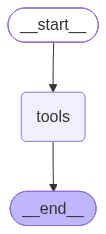

In [19]:
class State(MessagesState):
    user_id: str


@dataclass
class Context:
    organization_id: str


@tool
def get_user_info(runtime: ToolRuntime[Context, State]) -> str:
    """Look up user information."""
    # Read the current graph state passed to the ToolNode.
    user_id = runtime.state["user_id"]

    # Read explicit per-run values that are not part of graph state.
    organization_id = runtime.context.organization_id

    return f"User {user_id} in organization {organization_id}"


builder = StateGraph(State, context_schema=Context)
builder.add_node("tools", ToolNode([get_user_info]))
builder.add_edge(START, "tools")
graph = builder.compile()

show_graph(graph)

result = graph.invoke(
    {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "get_user_info",
                        "args": {},
                        "id": "call_user_info",
                    }
                ],
            )
        ],
        "user_id": "user_123",
    },
    context=Context(organization_id="org_456"),
)